In [ ]:
with open("/mnt/d/forCoding_code/_init_tools/x__params.py", "r") as f:
    txt = f.read()
exec(txt)

with open("/mnt/d/forCoding_code/_init_tools/report_macro_0516.py", "r") as f:
    txt = f.read()
exec(txt)

with open("/mnt/d/forCoding_code/_init_tools/x__tool_here1.py", "r") as f:
    exec(f.read())
with open("/mnt/d/forCoding_code/_init_tools/x__tool_here2.py", "r") as f:
    exec(f.read())

wasted_dir = "./wasted"
if not os.path.exists(wasted_dir):
    os.makedirs(wasted_dir)

pd.set_option('display.max_rows',200)
pd.set_option('display.max_columns',200)

In [20]:
def check_one_yang_crosses_four_ma(file_path):
    """
    判断股票在过去的8个交易周内，是否有过某一周出现“一阳从下到上穿过5、10、20、30日均线”的情况。
    并返回满足条件的日期列表。
    
    参数:
    file_path (str): 股票数据CSV文件的绝对路径
    
    返回:
    list: 满足条件的周日期列表（字符串格式）
    """
    if not os.path.exists(file_path):
        print(f"文件不存在: {file_path}")
        return []

    try:
        # 加载数据
        df = pd.read_csv(file_path)
        
        # 确保按日期升序排列
        if 'date' not in df.columns:
            print("CSV中未找到 'date' 列")
            return []
            
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date')
        
        # 计算 5, 10, 20, 30 周移动平均线 (MA)
        for window in [5, 10, 20, 30]:
            df[f'ma{window}'] = df['close'].rolling(window=window).mean()
        
        # 获取最近 8 个交易周的数据
        # 注意：需要确保有足够的历史数据来计算 MA30
        if len(df) < 30:
            print("数据量不足 30 周，无法计算 MA30")
            return []
            
        recent_8_weeks = df.tail(2).copy()
        
        matching_dates = []
        
        for index, row in recent_8_weeks.iterrows():
            date_str = row['date'].strftime('%Y-%m-%d')
            open_price = row['open']
            close_price = row['close']
            
            # 获取均线值
            mas = [row[f'ma{w}'] for w in [5, 10, 20, 30]]
            
            # 检查均线是否有效 (非 NaN)
            if any(pd.isna(m) for m in mas):
                continue
            
            min_ma = min(mas)
            max_ma = max(mas)
            
            # 条件判断：
            # 1. 必须是阳线 (收盘价 > 开盘价)
            # 2. 开盘价必须低于所有四条均线 (从下)
            # 3. 收盘价必须高于所有四条均线 (到上)
            is_yang = close_price > open_price
            is_below_all = open_price < min_ma
            is_above_all = close_price > max_ma
            
            if is_yang and is_below_all and is_above_all:
                matching_dates.append(date_str)
                
        return matching_dates
        
    except Exception as e:
        print(f"处理文件 {file_path} 时出错: {e}")
        return []

# if __name__ == "__main__":
# 目标文件路径
target_file = "/mnt/d/forCoding_data/QuantFinance/plan_1-select_stock_by_week/originalData/sh.600004.csv"

print(f"正在检查文件: {target_file}")
found_weeks = check_one_yang_crosses_four_ma(target_file)

if found_weeks:
    print(f"结果: 发现满足‘一阳穿四线’模式的周！")
    print("具体日期如下:")
    for date in found_weeks:
        print(f"  - {date}")
else:
    print(f"结果: 过去8周内未发现满足该模式的周。")

正在检查文件: /mnt/d/forCoding_data/QuantFinance/plan_1-select_stock_by_week/originalData/sh.600004.csv
结果: 过去8周内未发现满足该模式的周。


In [48]:
stoch_list = pd.read_csv("all_stock_list.csv")

In [51]:
stock_name_map = {k:v for k, v in zip(stoch_list.code, stoch_list.code_name)}

In [22]:
DATA_DIR = "/mnt/d/forCoding_data/QuantFinance/plan_1-select_stock_by_week/originalData/"

In [23]:
# 获取所有csv文件
files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
print(f"找到 {len(files)} 个CSV文件，开始扫描...")

results = {}

# 使用 tqdm 显示进度
for filename in tqdm.tqdm(files):
    file_path = os.path.join(DATA_DIR, filename)
    
    # 提取股票代码 (假设文件名格式为 code.csv)
    stock_code = os.path.splitext(filename)[0]

    found_weeks = check_one_yang_crosses_four_ma(file_path)
    if found_weeks:
        results[stock_code] = found_weeks

找到 6120 个CSV文件，开始扫描...


  7%|█████▉                                                                         | 457/6120 [00:02<00:32, 175.29it/s]

数据量不足 30 周，无法计算 MA30
数据量不足 30 周，无法计算 MA30
数据量不足 30 周，无法计算 MA30
数据量不足 30 周，无法计算 MA30


  8%|██████▋                                                                        | 515/6120 [00:03<00:31, 180.31it/s]

数据量不足 30 周，无法计算 MA30
数据量不足 30 周，无法计算 MA30
数据量不足 30 周，无法计算 MA30
数据量不足 30 周，无法计算 MA30


...

数据量不足 30 周，无法计算 MA30
数据量不足 30 周，无法计算 MA30


100%|█████████████████████████████████████████████████████████████████████████████▊| 6106/6120 [00:29<00:00, 185.30it/s]

数据量不足 30 周，无法计算 MA30
数据量不足 30 周，无法计算 MA30
数据量不足 30 周，无法计算 MA30


100%|██████████████████████████████████████████████████████████████████████████████| 6120/6120 [00:30<00:00, 203.60it/s]

数据量不足 30 周，无法计算 MA30
数据量不足 30 周，无法计算 MA30
数据量不足 30 周，无法计算 MA30
数据量不足 30 周，无法计算 MA30
数据量不足 30 周，无法计算 MA30
数据量不足 30 周，无法计算 MA30


In [24]:
len(results)

199

In [28]:
results.keys()

dict_keys(['sh.600008', 'sh.600010', 'sh.600017', 'sh.600023', 'sh.600035', 'sh.600116', 'sh.600121', 'sh.600125', 'sh.600150', 'sh.600168', 'sh.600195', 'sh.600207', 'sh.600222', 'sh.600227', 'sh.600255', 'sh.600281', 'sh.600310', 'sh.600371', 'sh.600398', 'sh.600483', 'sh.600511', 'sh.600512', 'sh.600528', 'sh.600537', 'sh.600540', 'sh.600545', 'sh.600569', 'sh.600573', 'sh.600641', 'sh.600645', 'sh.600681', 'sh.600704', 'sh.600726', 'sh.600742', 'sh.600744', 'sh.600758', 'sh.600769', 'sh.600782', 'sh.600787', 'sh.600803', 'sh.600866', 'sh.600956', 'sh.600960', 'sh.600979', 'sh.601003', 'sh.601065', 'sh.601083', 'sh.601326', 'sh.601330', 'sh.601515', 'sh.601669', 'sh.601727', 'sh.601777', 'sh.601868', 'sh.601880', 'sh.601908', 'sh.603118', 'sh.603208', 'sh.603257', 'sh.603269', 'sh.603310', 'sh.603321', 'sh.603330', 'sh.603333', 'sh.603527', 'sh.603580', 'sh.603602', 'sh.603689', 'sh.603693', 'sh.603855', 'sh.605018', 'sh.605158', 'sh.605555', 'sh.688035', 'sh.688093', 'sh.688099', '

In [43]:
def check_last_close_below_threshold(stock_code, threshold=30):
    """
    加载指定股票的数据，判断其最后一个收盘价是否在阈值以下。
    
    参数:
    stock_code (str): 股票编号，如 '600004', 'sh.600004'
    threshold (float): 阈值，默认为 30
    
    返回:
    bool: 如果最后收盘价 < threshold 返回 True，否则返回 False
    """
    # 1. 尝试查找对应文件
    # 支持输入 '600004' 自动匹配 'sh.600004.csv' 或 'sz.600004.csv'
    # 也支持输入 'sh.600004' 直接匹配
    
    candidate_files = []
    
    # 如果输入包含 . (如 sh.600004)，优先找完全匹配
    if '.' in stock_code:
        candidate_files.append(f"{stock_code}.csv")
    else:
        # 如果只是数字，尝试常见前缀
        candidate_files.append(f"sh.{stock_code}.csv")
        candidate_files.append(f"sz.{stock_code}.csv")
        candidate_files.append(f"bj.{stock_code}.csv")
        candidate_files.append(f"{stock_code}.csv") # 可能没有前缀
        
    target_path = None
    for fname in candidate_files:
        path = os.path.join(DATA_DIR, fname)
        if os.path.exists(path):
            target_path = path
            break
            
    if not target_path:
        print(f"未找到股票 {stock_code} 的数据文件 (尝试查找了: {candidate_files})")
        return False
        
    try:
        # 2. 加载数据
        # 只读取 date 和 close 列即可
        df = pd.read_csv(target_path)
        
        if df.empty:
            print(f"文件 {target_path} 为空")
            return False
            
        if 'close' not in df.columns:
            print(f"文件 {target_path} 缺少 'close' 列")
            return False
            
        # 3. 获取最后一个收盘价
        # 假设数据是按时间追加的，最后一行就是最新的。
        # 如果不放心，可以先按日期排序
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])
            df = df.sort_values('date')
            
        last_close = float(df.iloc[-1]['close'])
        last_date = df.iloc[-1]['date']
        if isinstance(last_date, pd.Timestamp):
            last_date_str = last_date.strftime('%Y-%m-%d')
        else:
            last_date_str = str(last_date)
            
        # print(f"股票 {stock_code} ({os.path.basename(target_path)}) 日期: {last_date_str}, 收盘价: {last_close}")
        
        if last_close < threshold:
            return True
        else:
            return False
            
    except Exception as e:
        print(f"处理文件 {target_path} 时出错: {e}")
        return False

test_code = "600004"
threshold = 10

selected_code = []
for sc in tqdm.tqdm(results.keys()):
    if check_last_close_below_threshold(sc, threshold):
        selected_code.append(sc)
len(selected_code)

100%|████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 226.11it/s]


98

In [44]:
!rm -rf ./k_plots

100%|███████████████████████████████████████████████████████████████████████████████████| 98/98 [00:15<00:00,  6.19it/s]


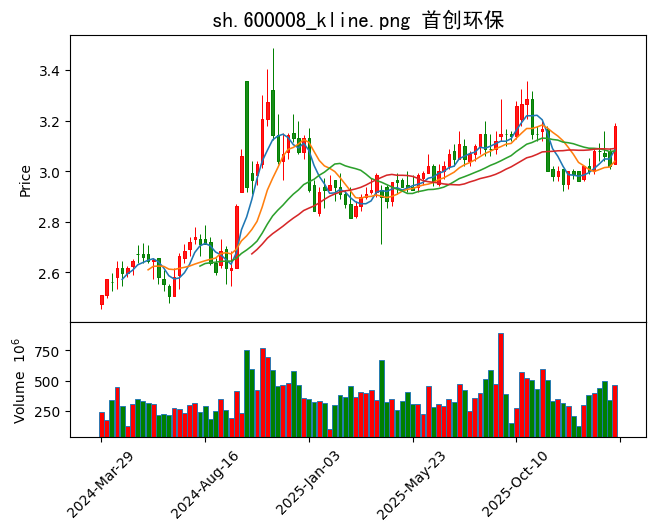

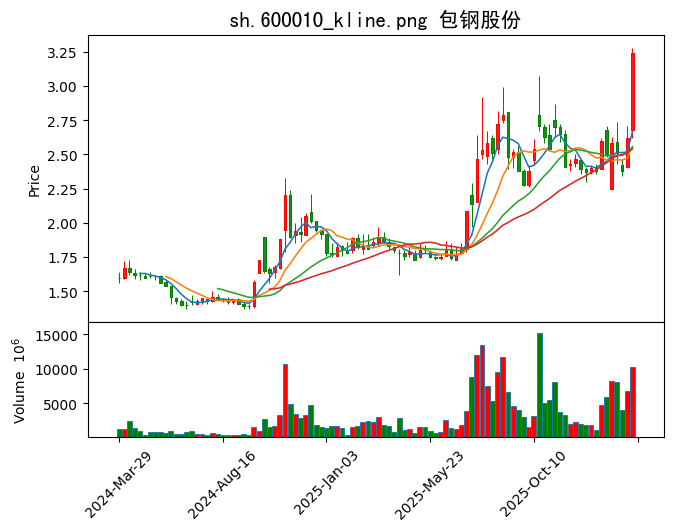

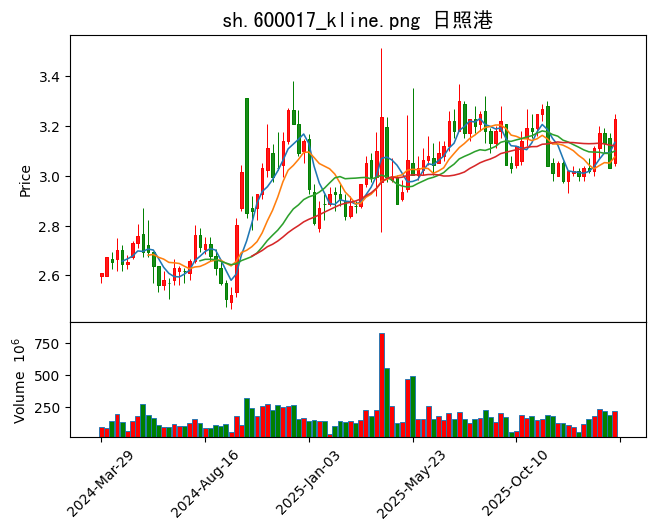

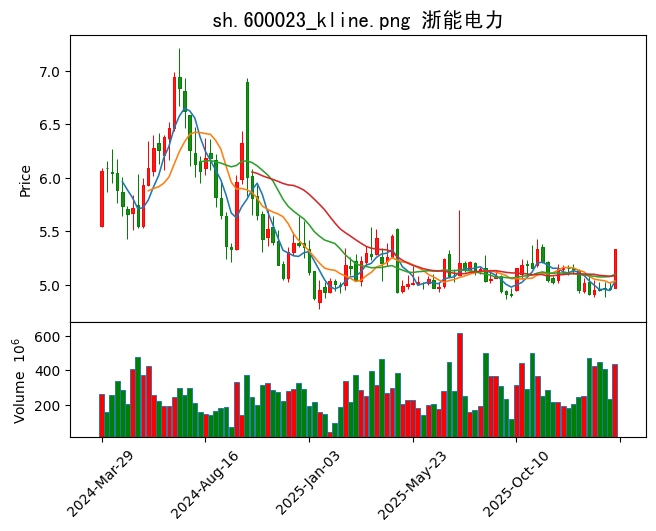

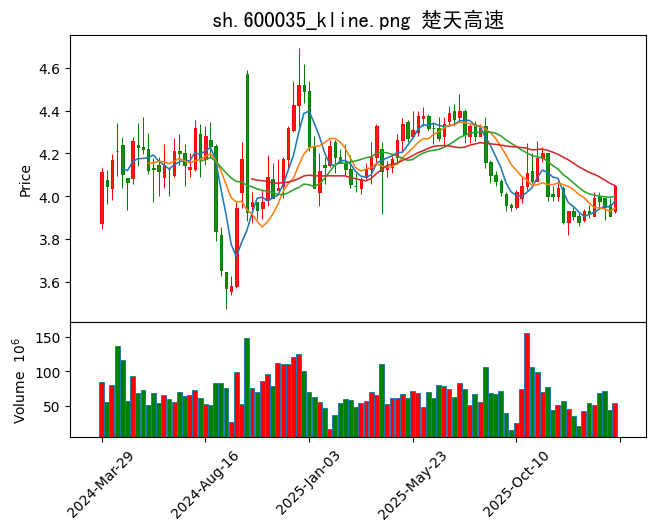

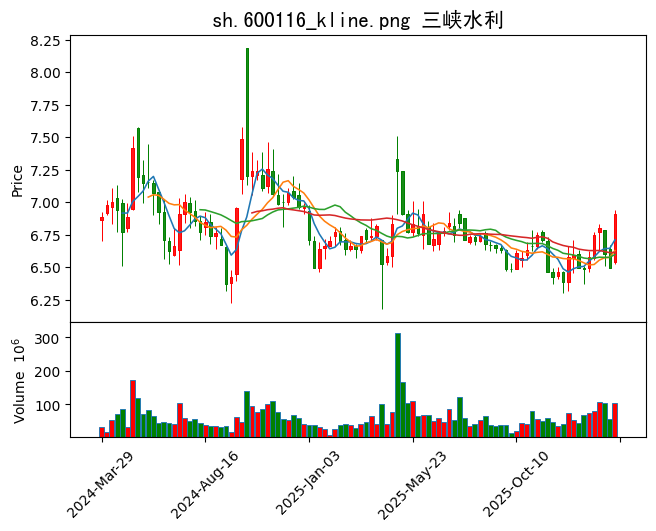

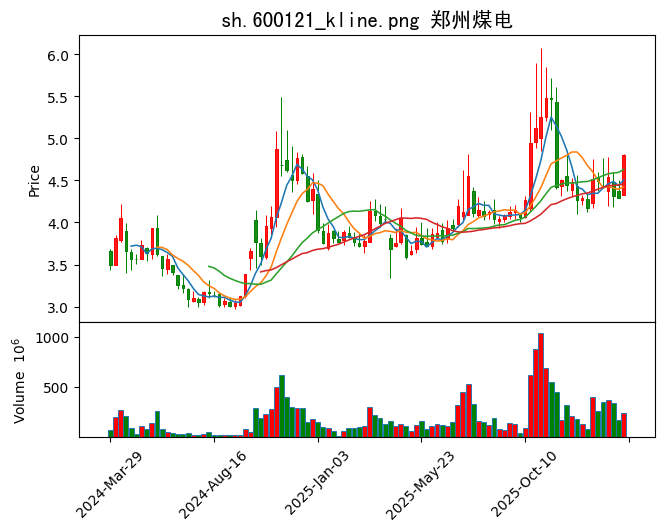

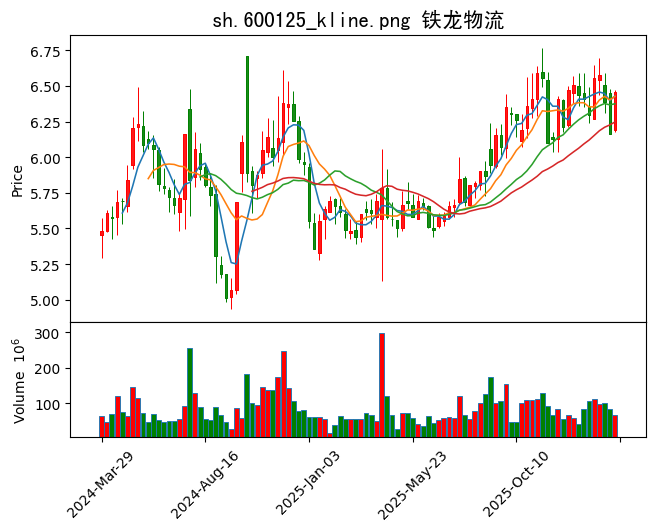

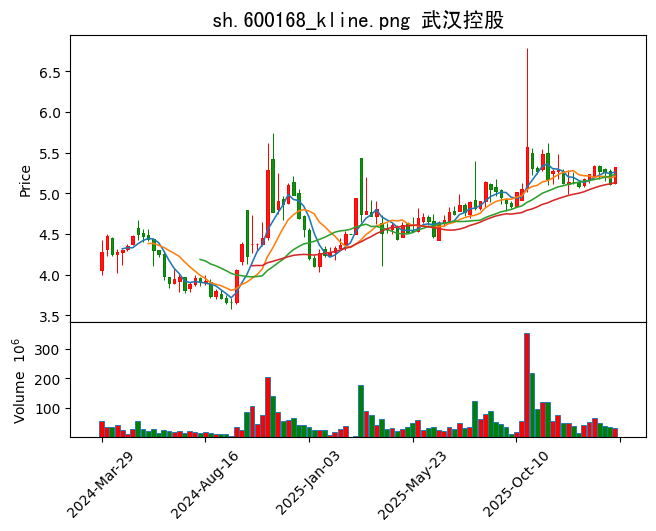

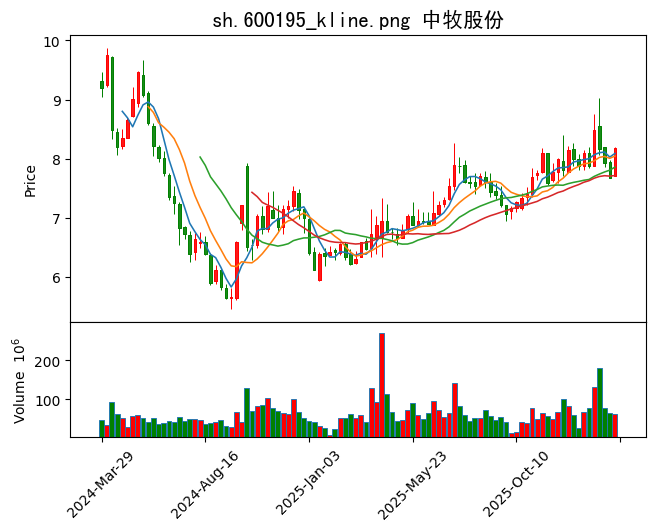

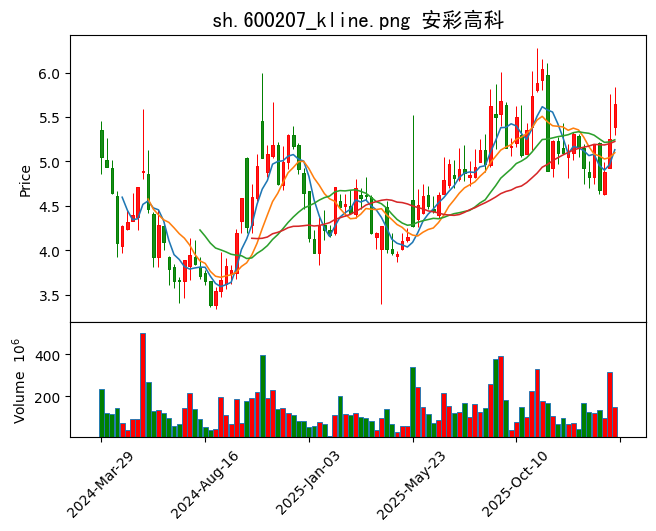

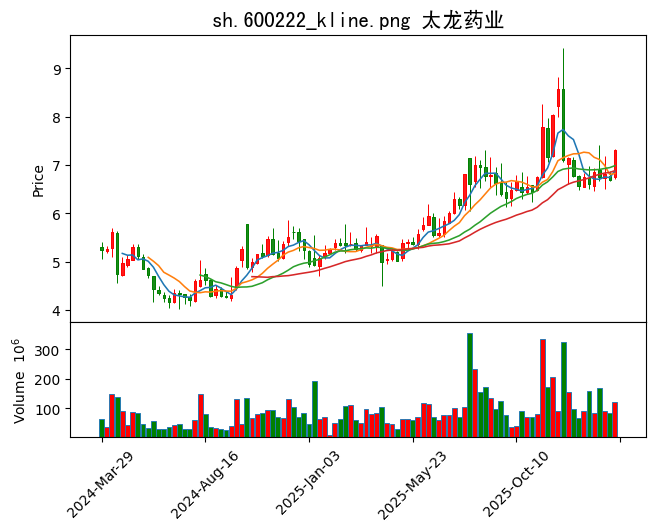

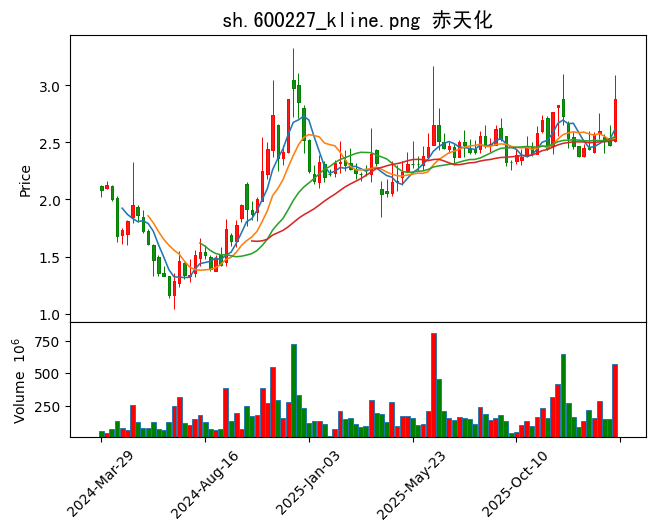

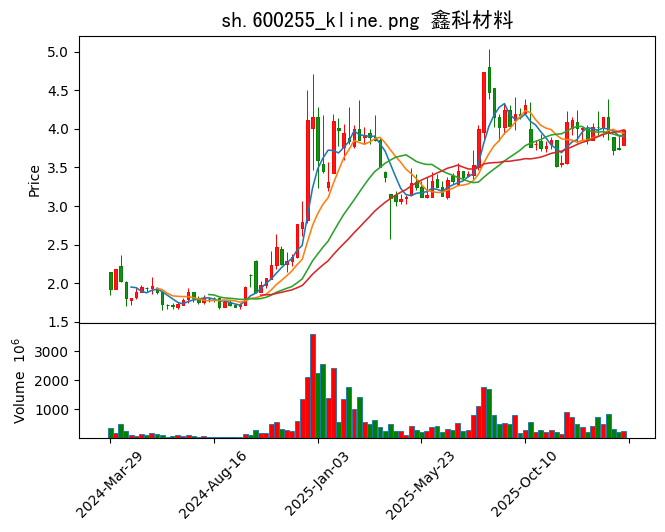

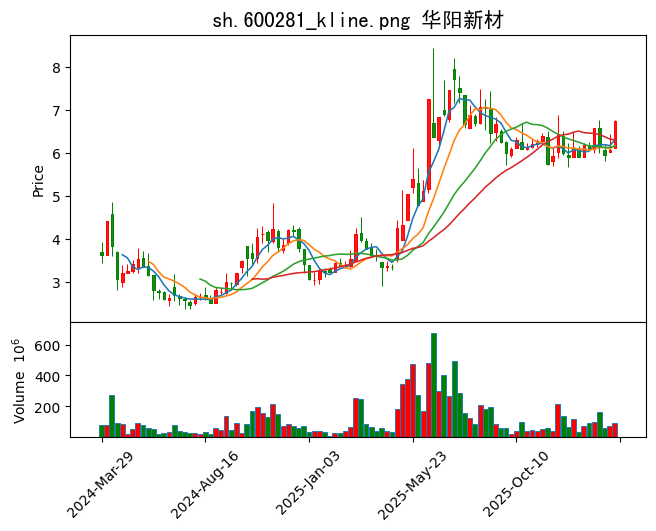

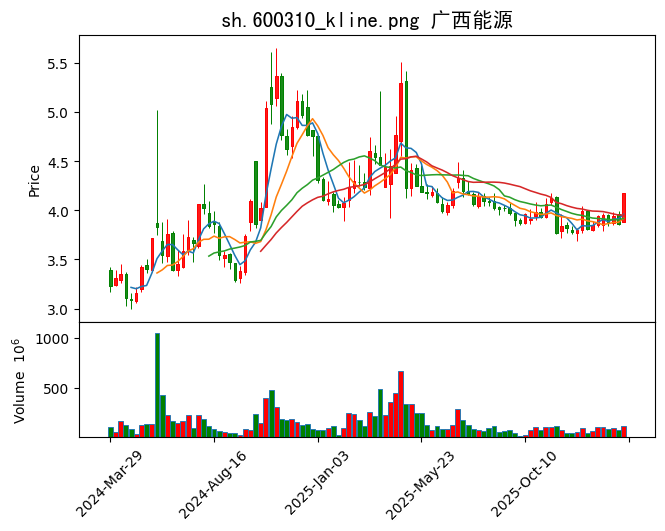

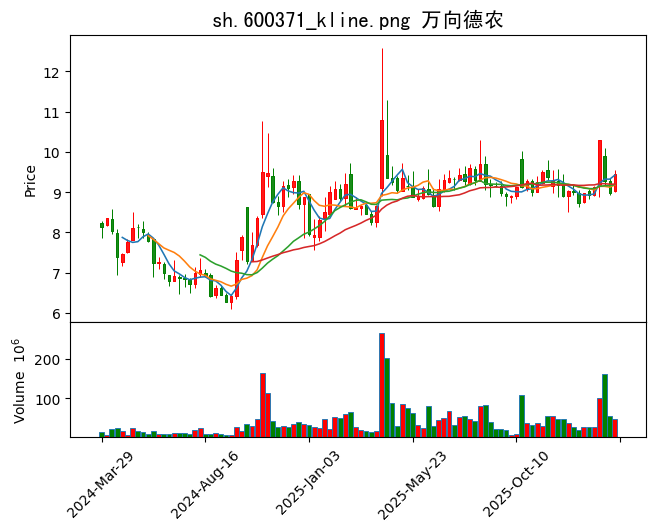

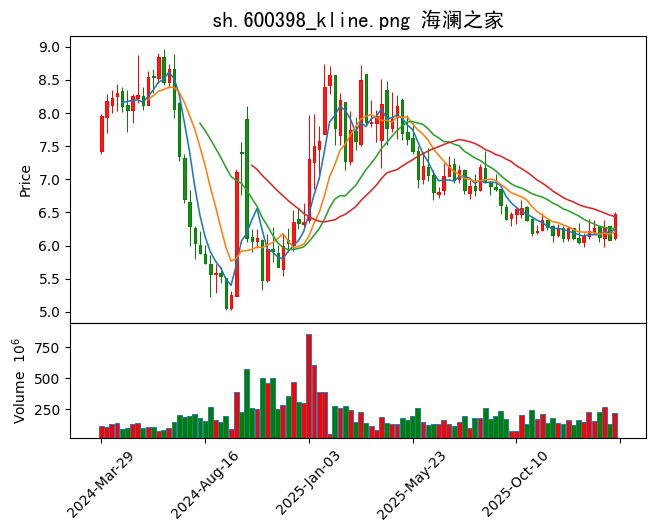

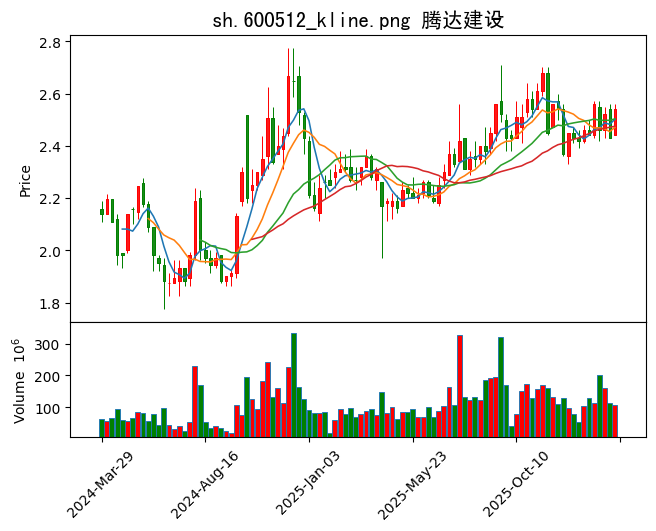

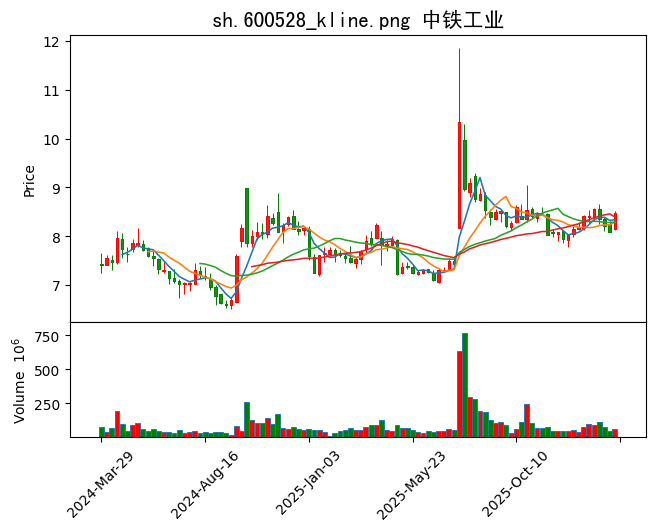

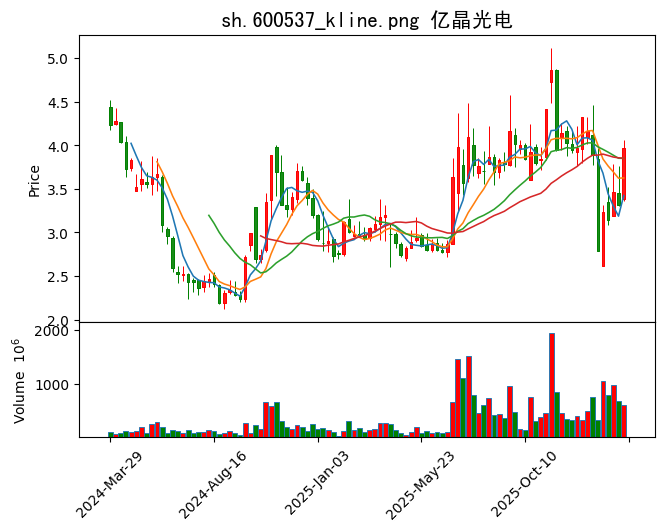

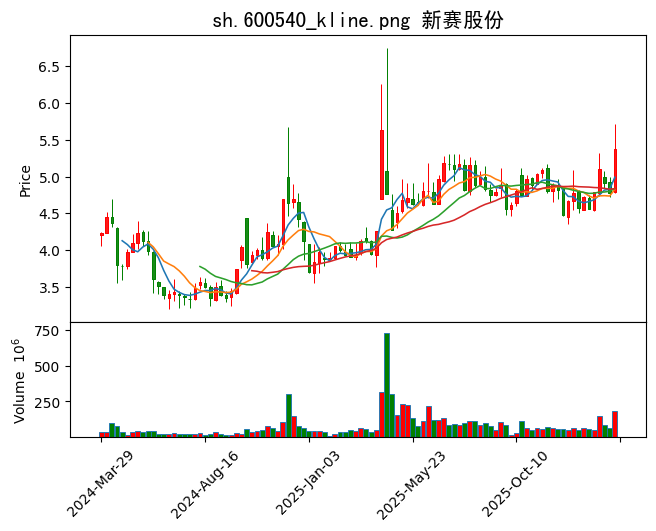

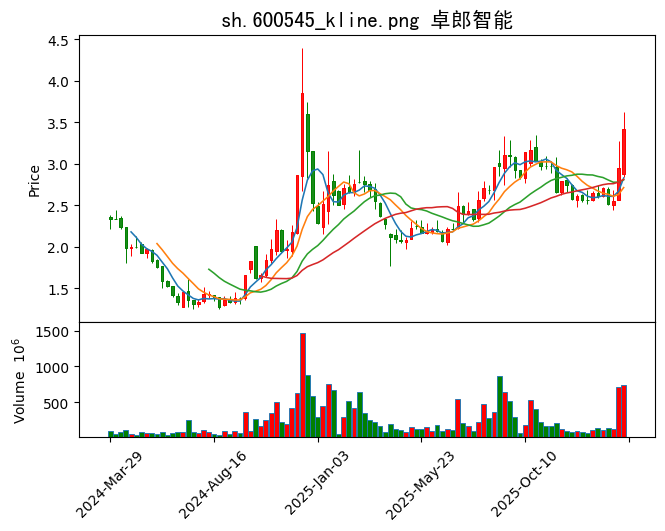

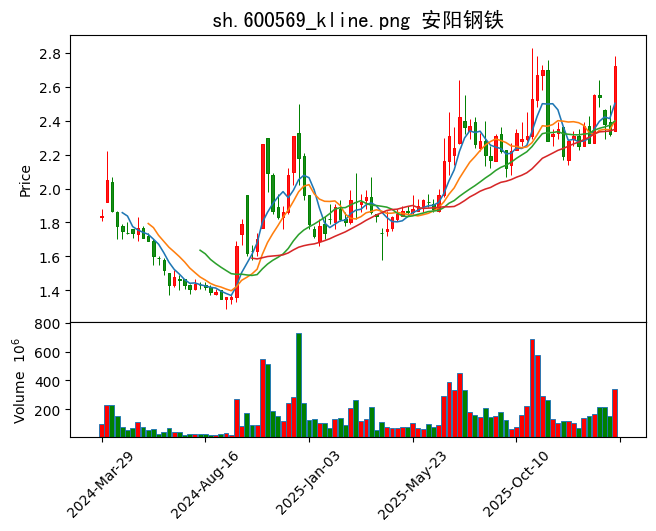

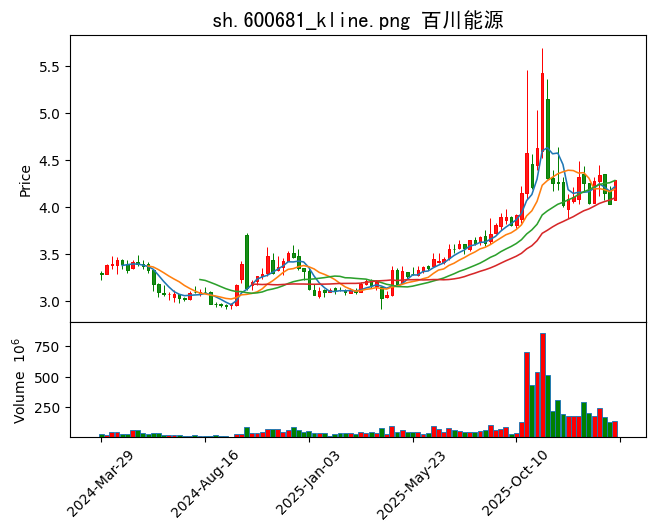

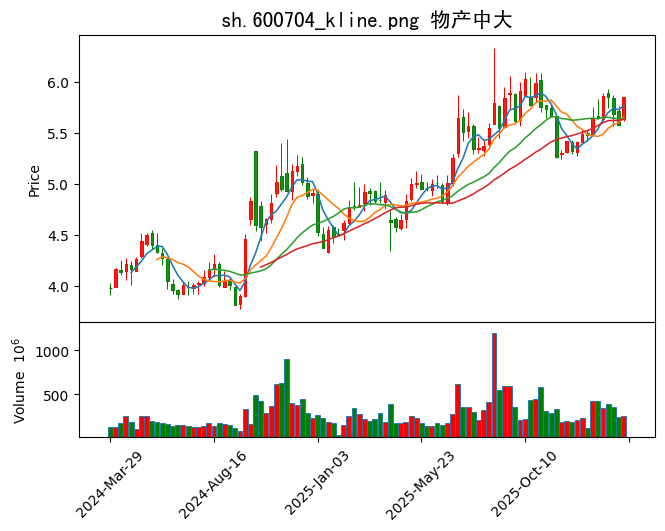

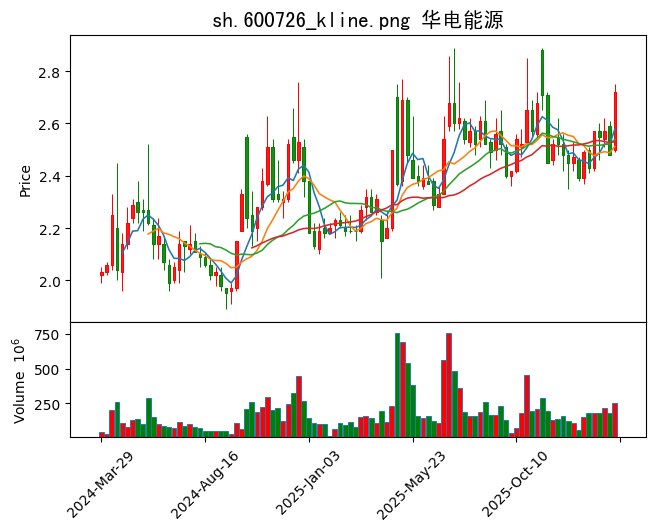

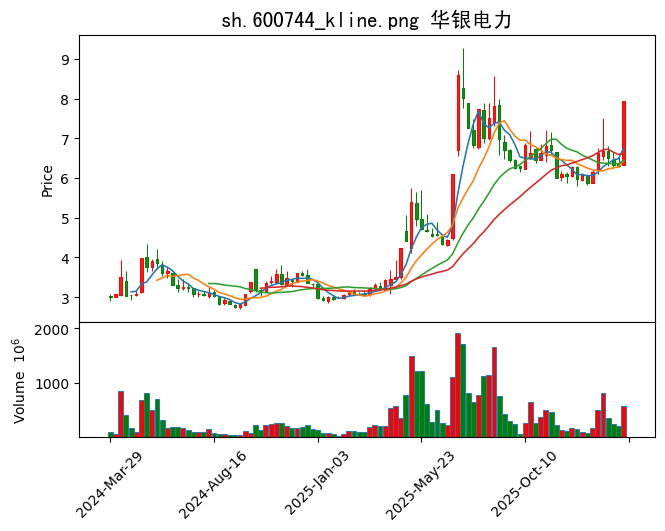

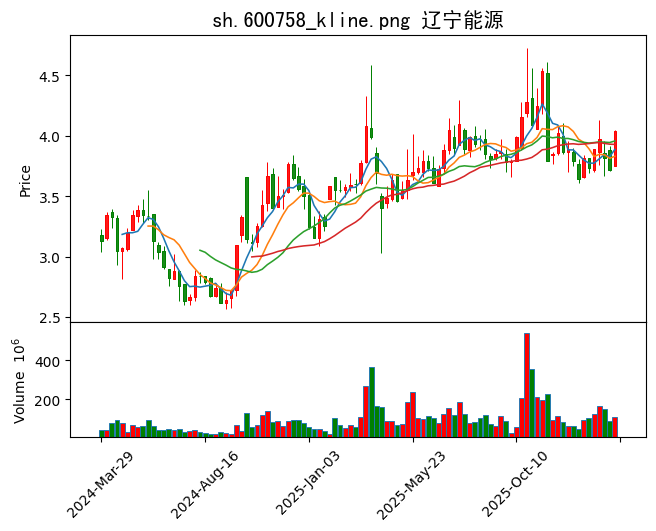

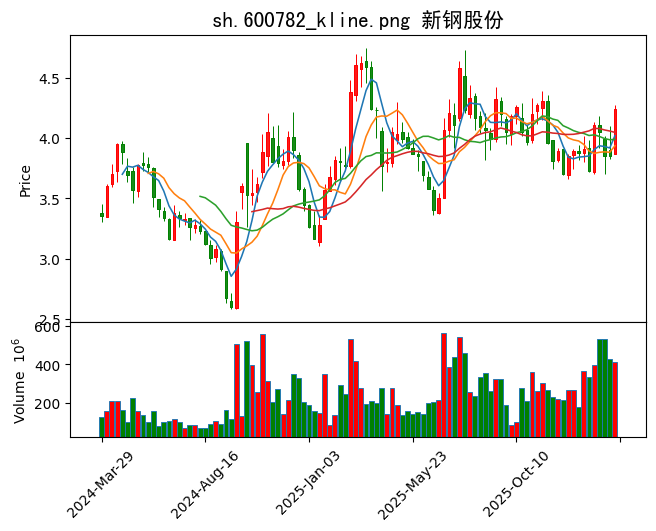

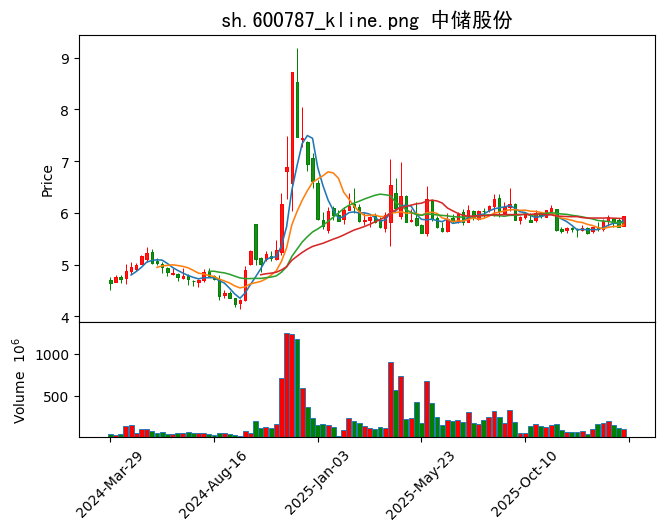

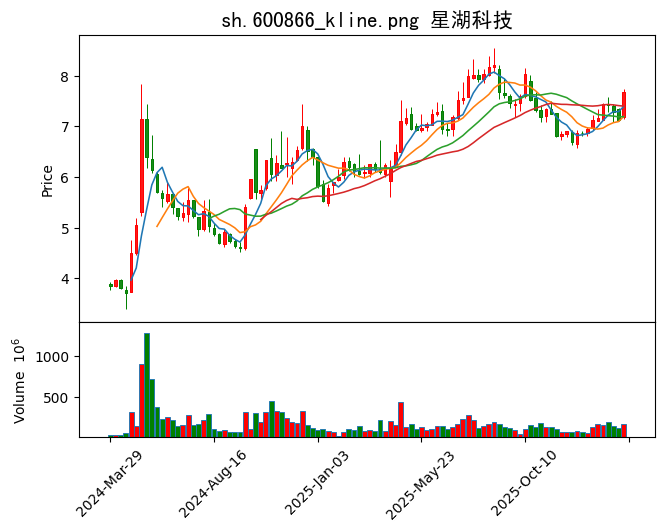

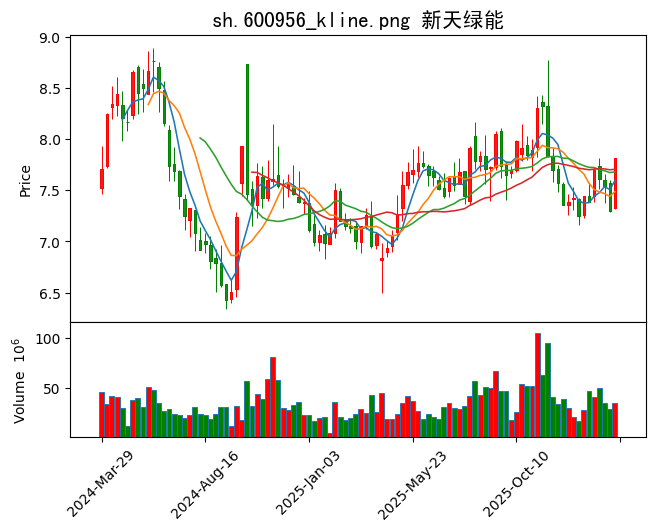

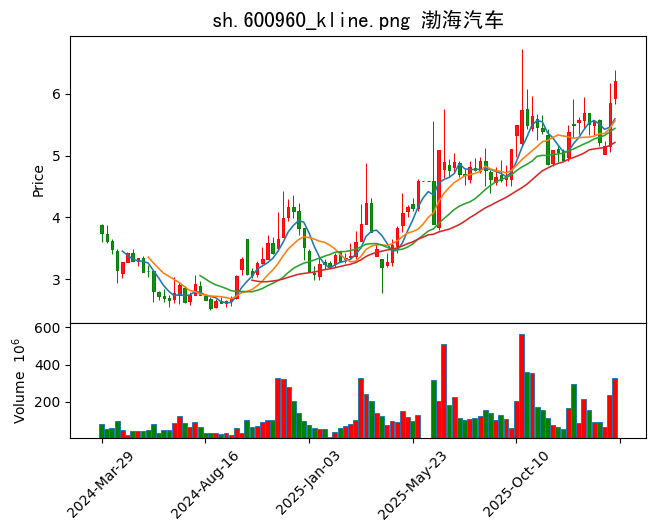

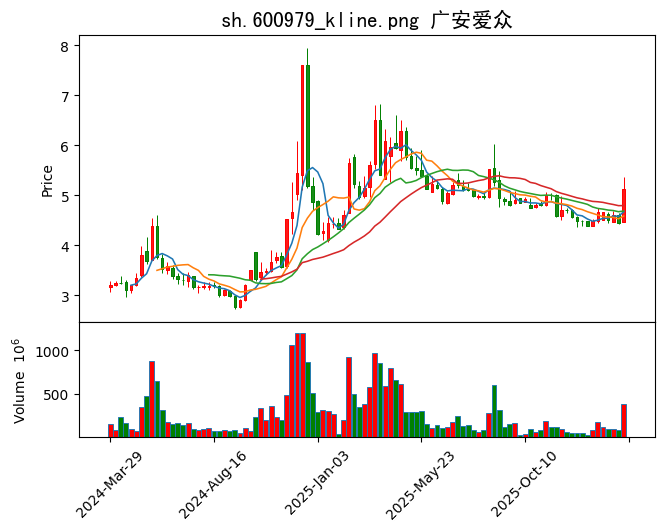

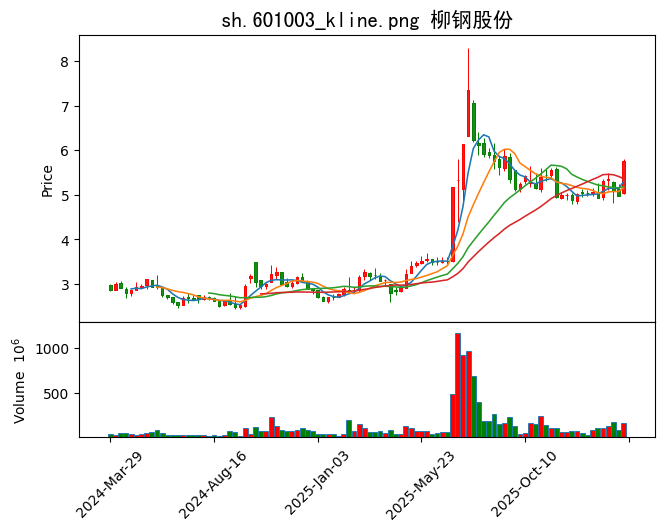

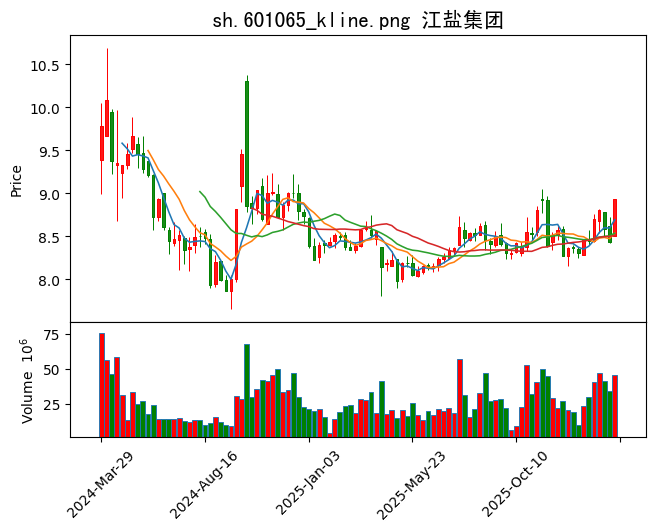

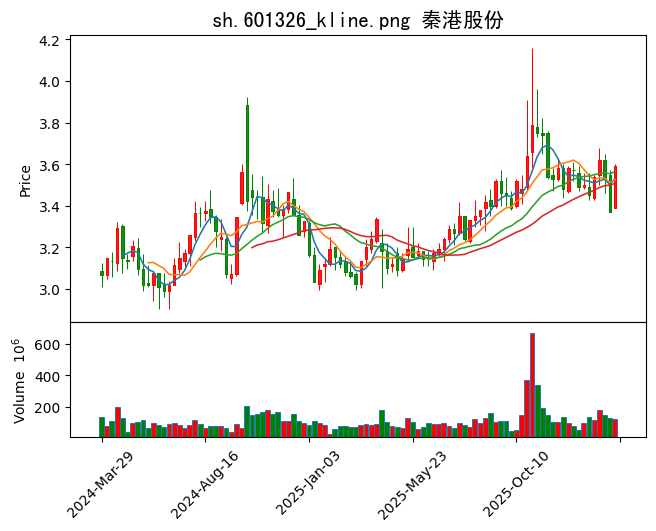

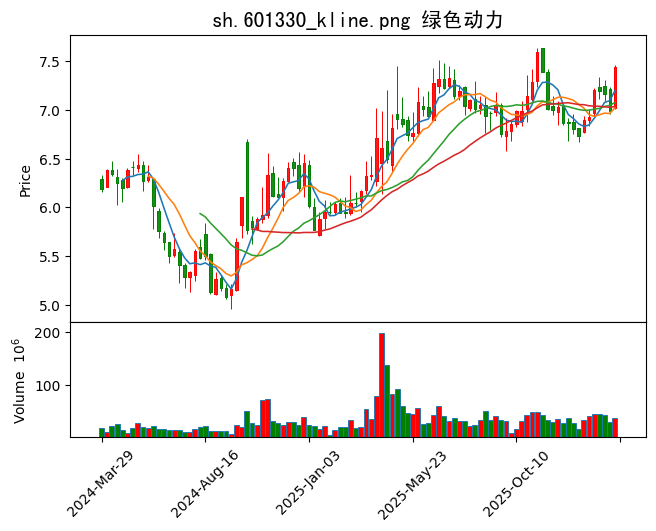

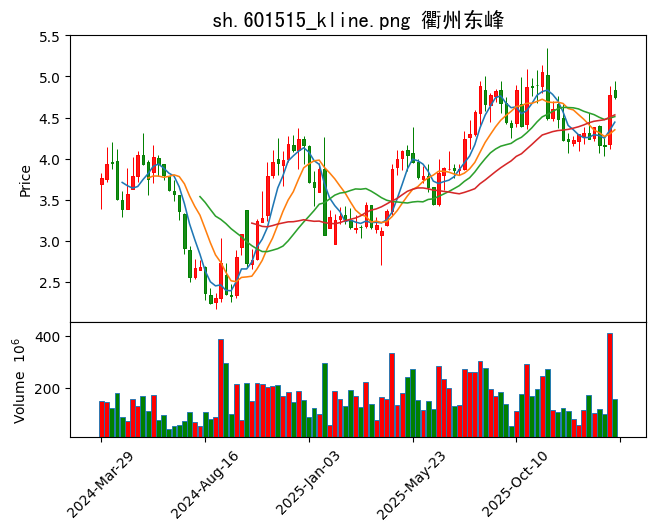

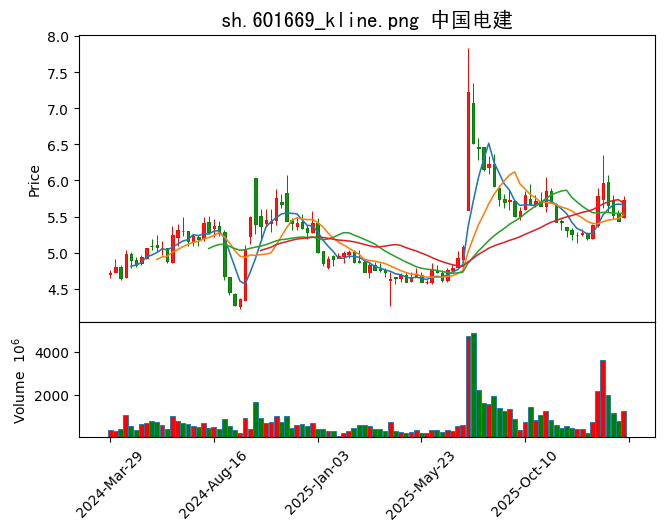

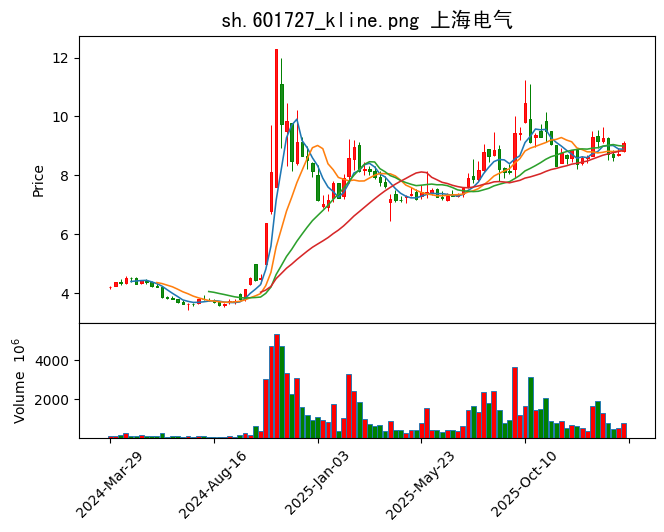

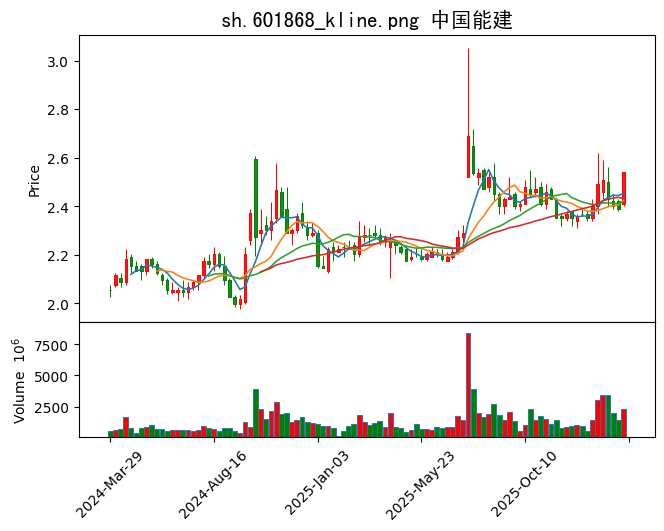

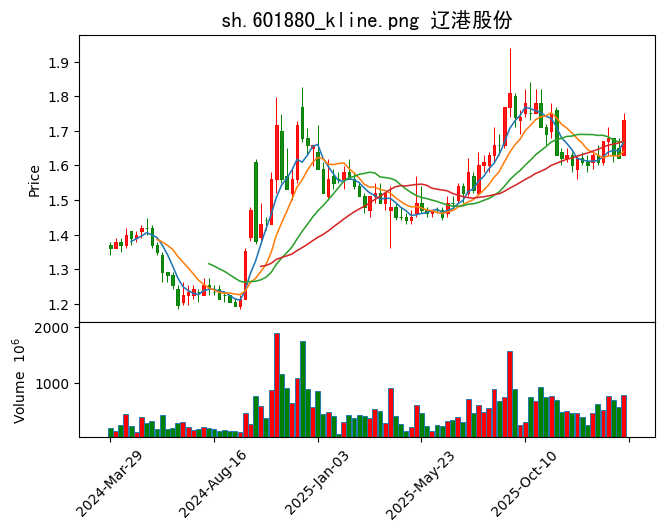

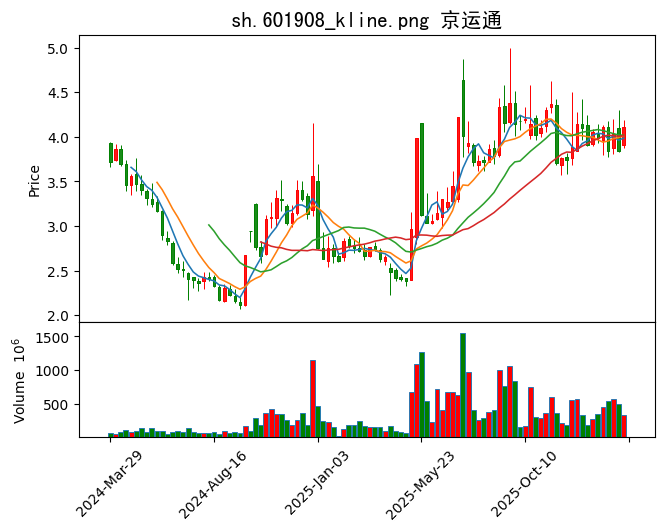

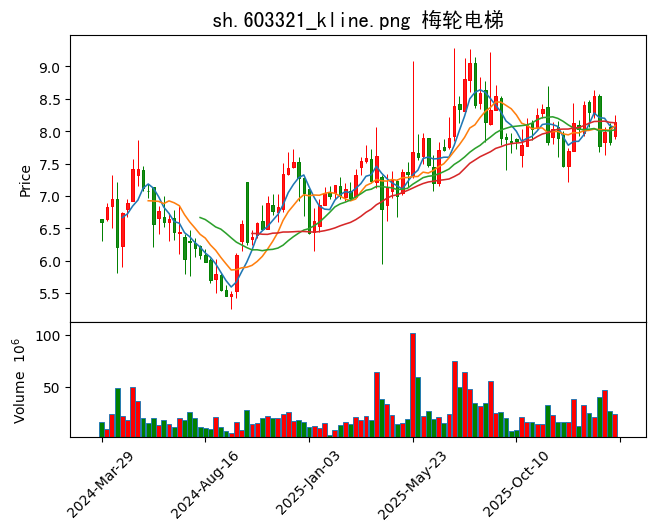

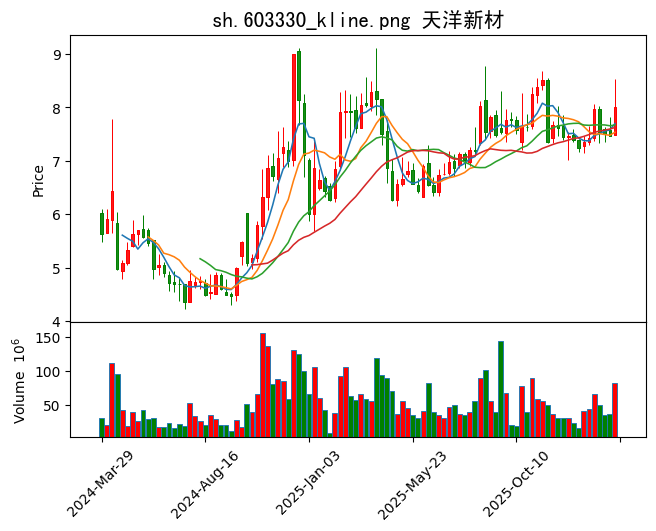

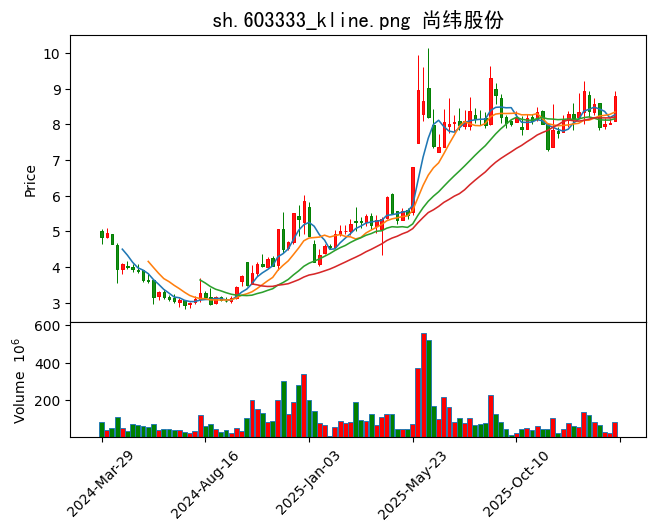

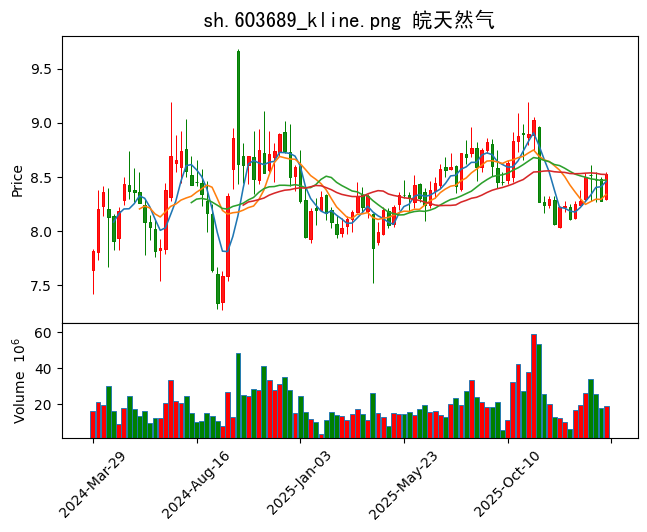

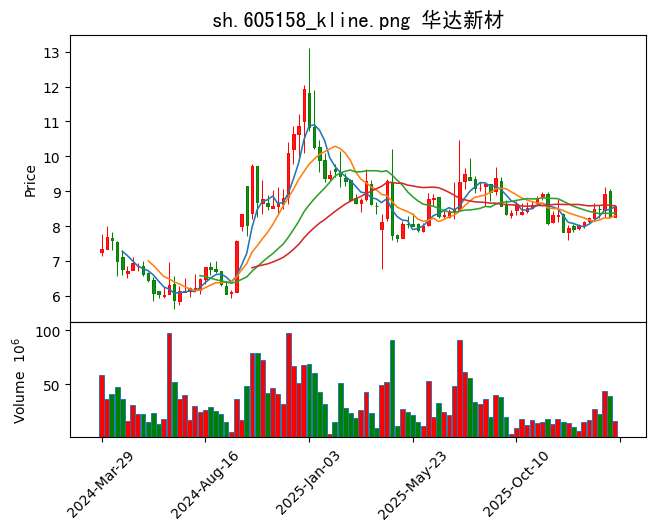

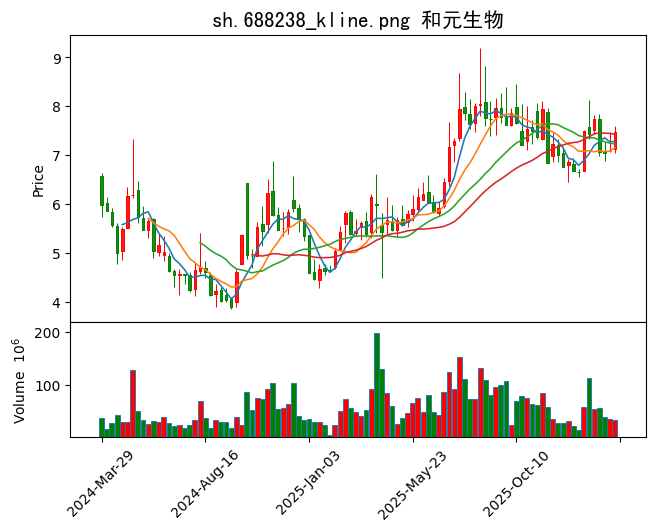

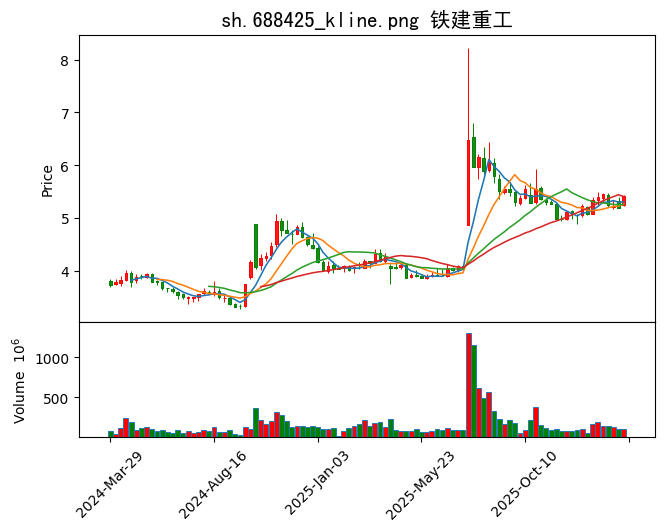

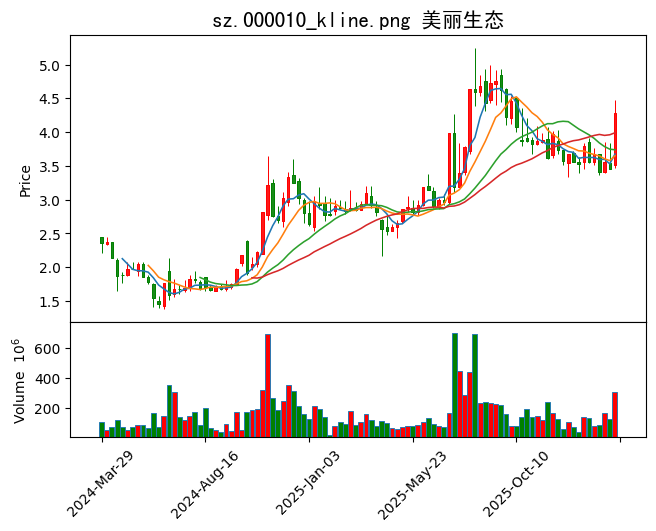

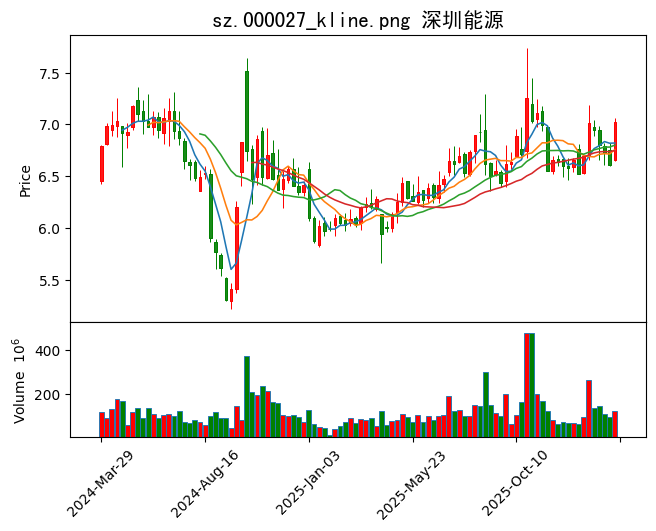

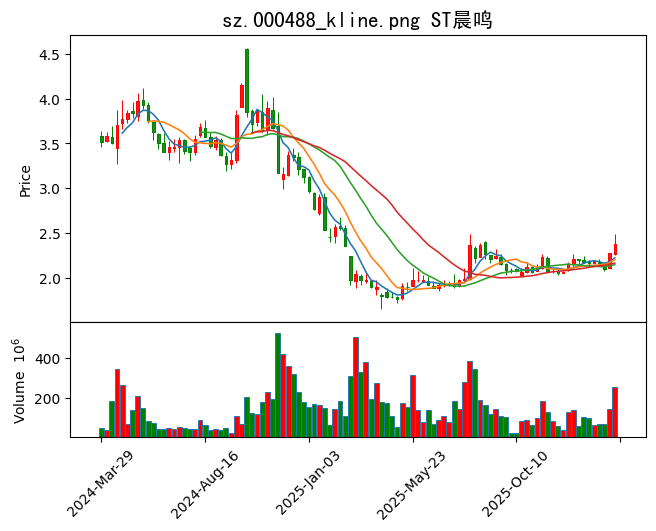

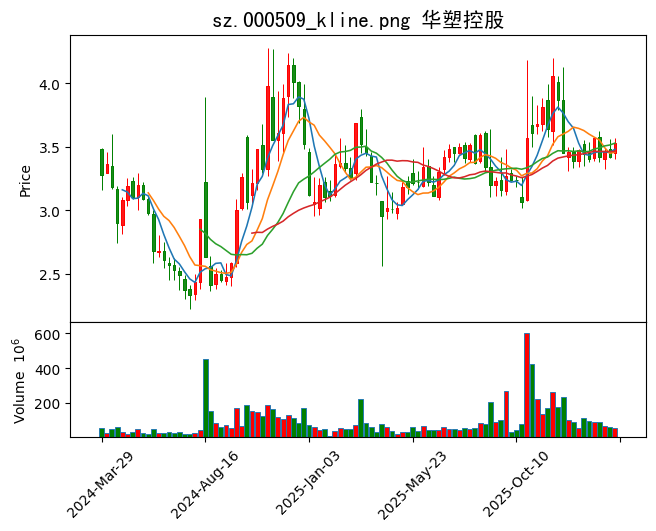

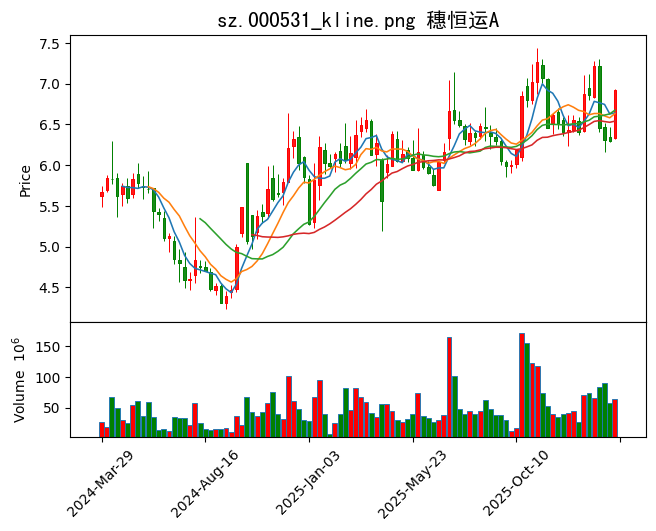

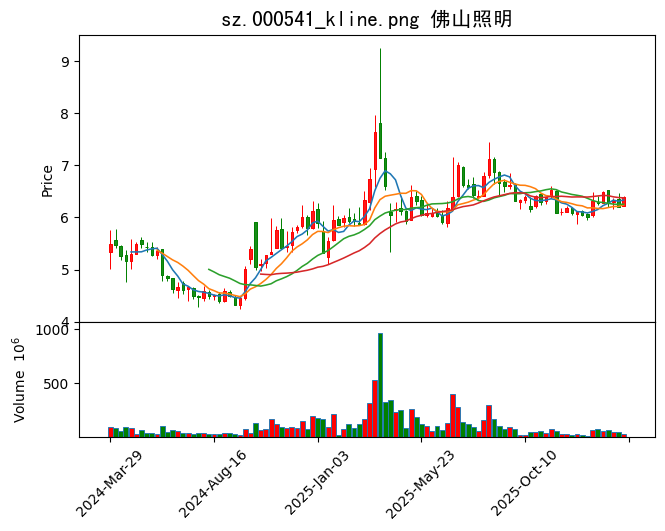

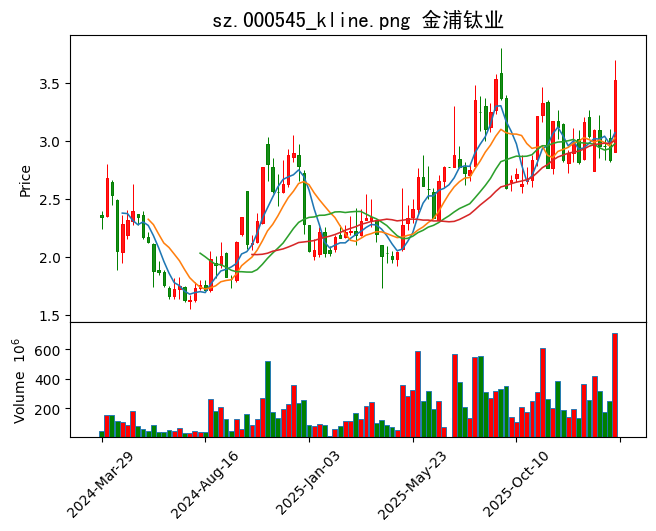

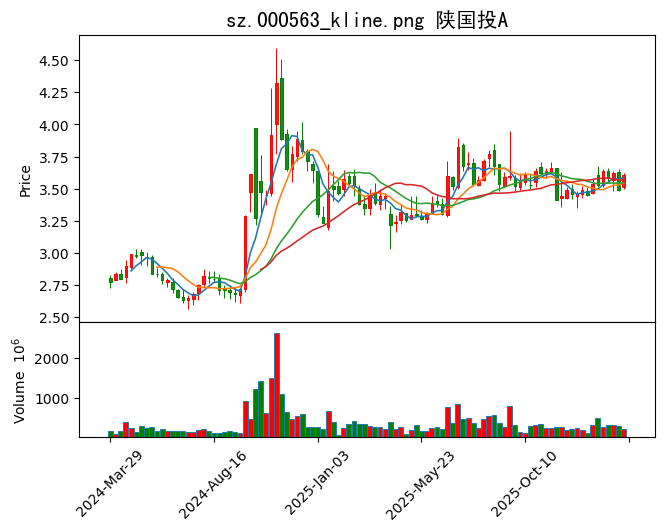

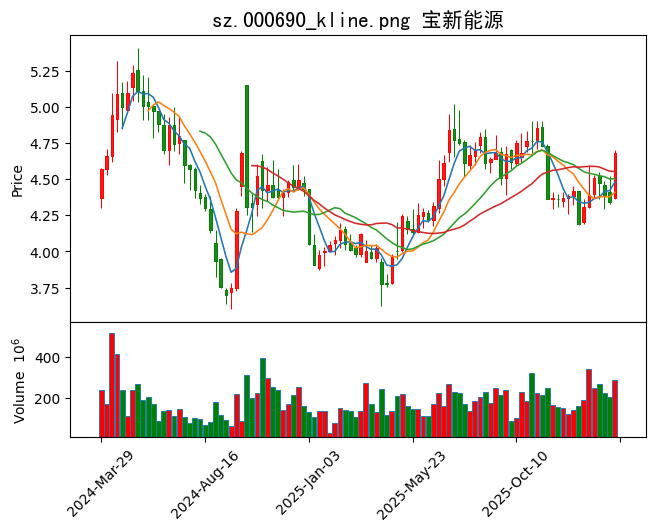

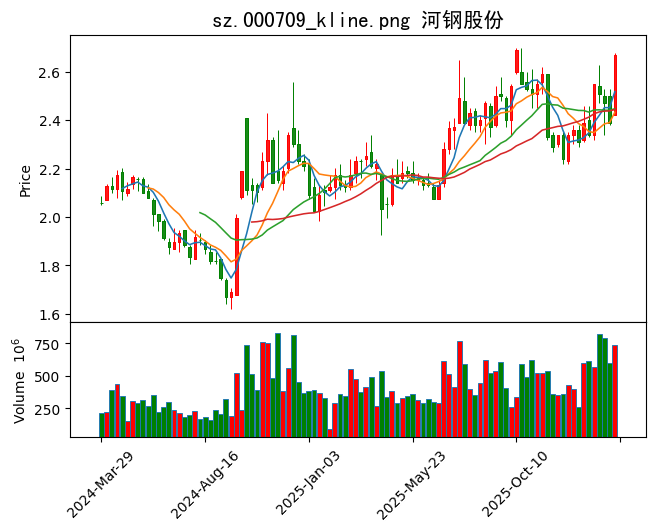

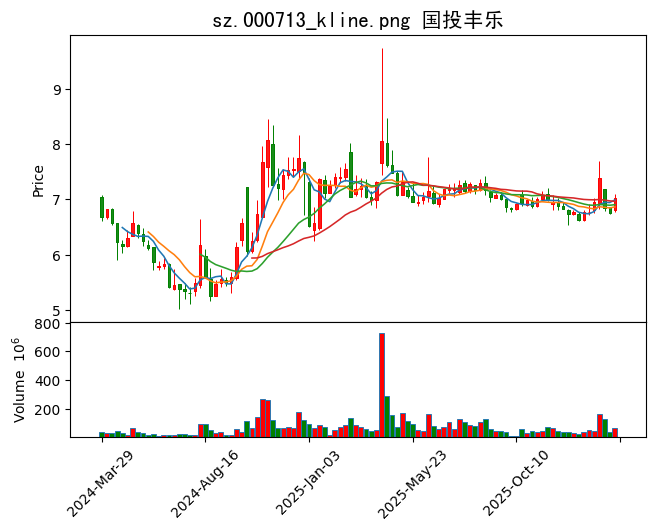

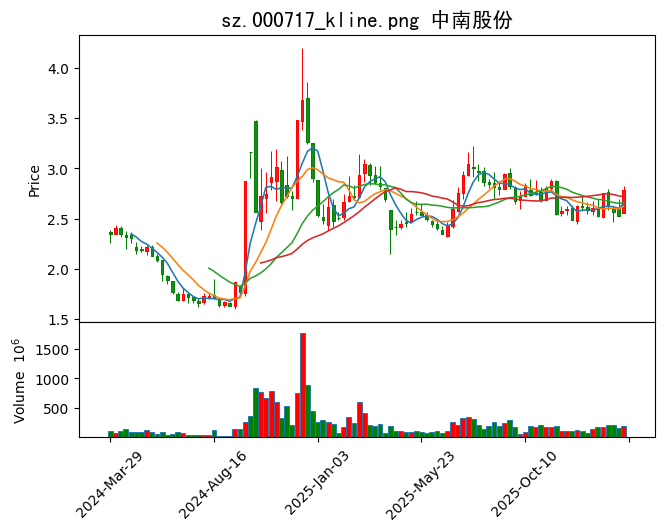

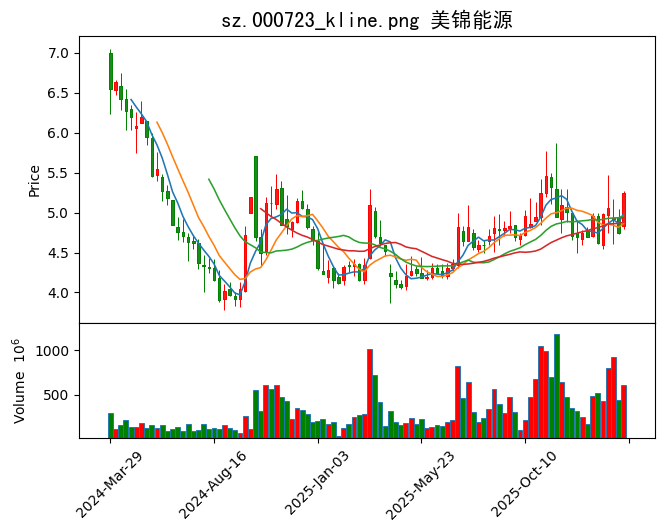

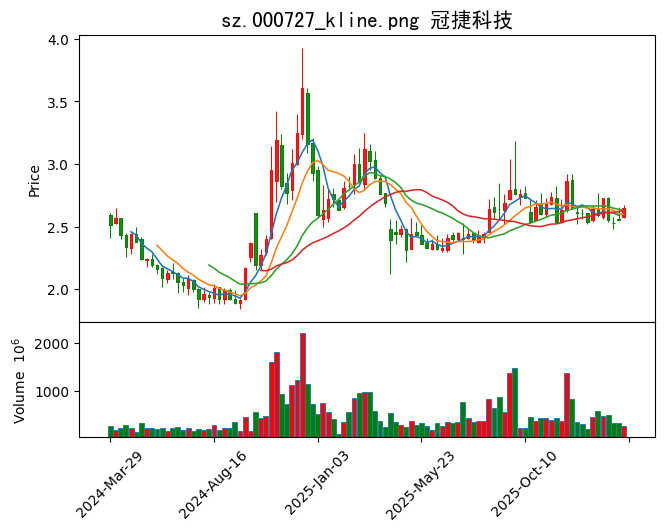

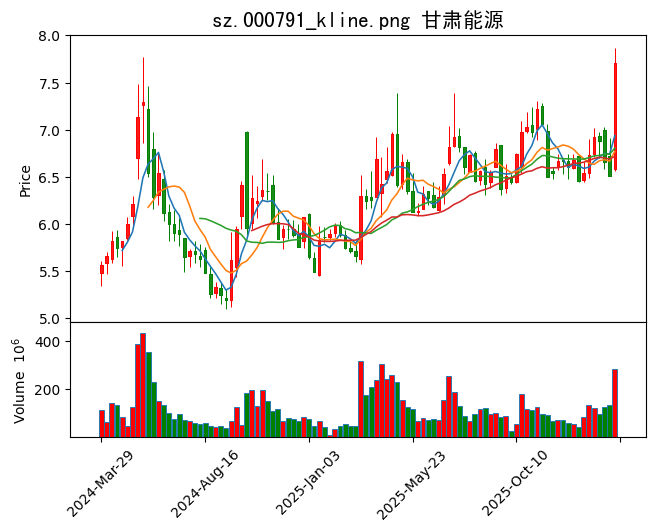

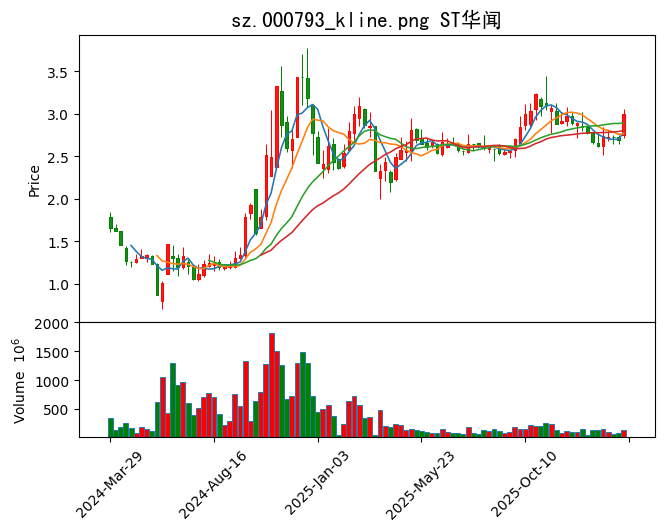

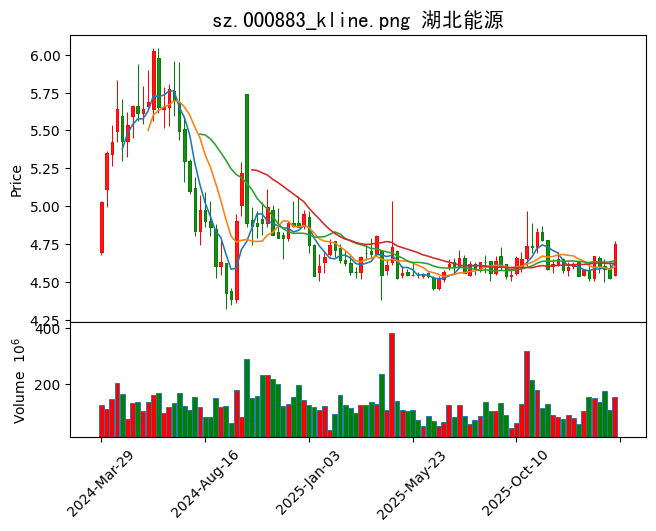

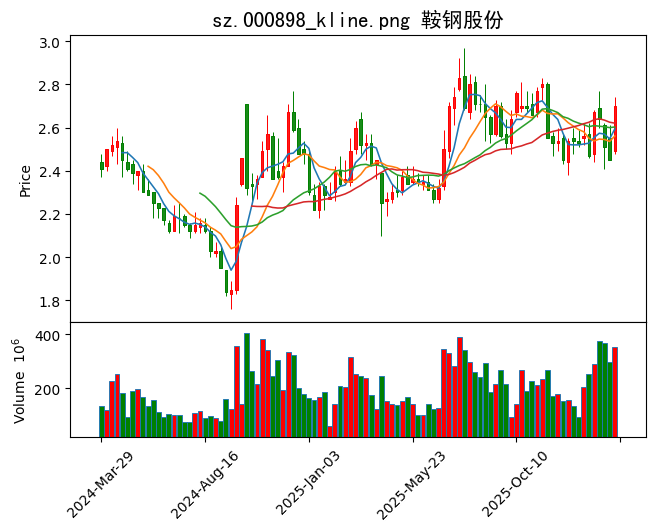

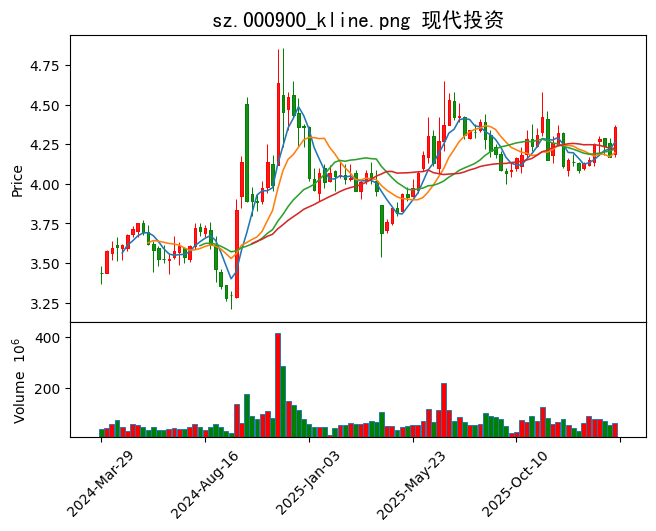

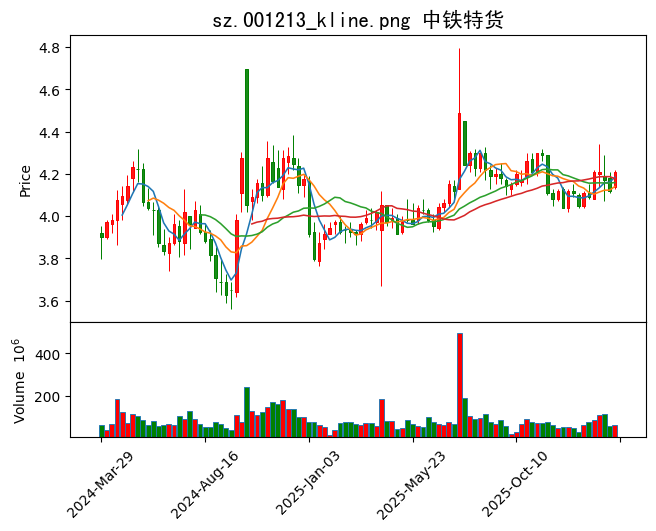

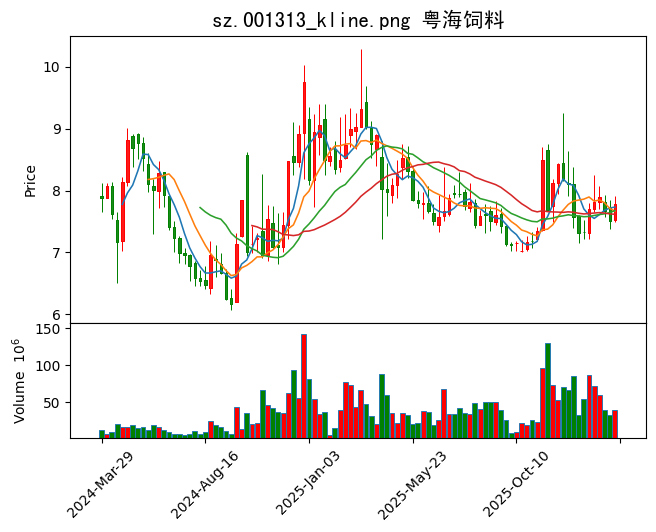

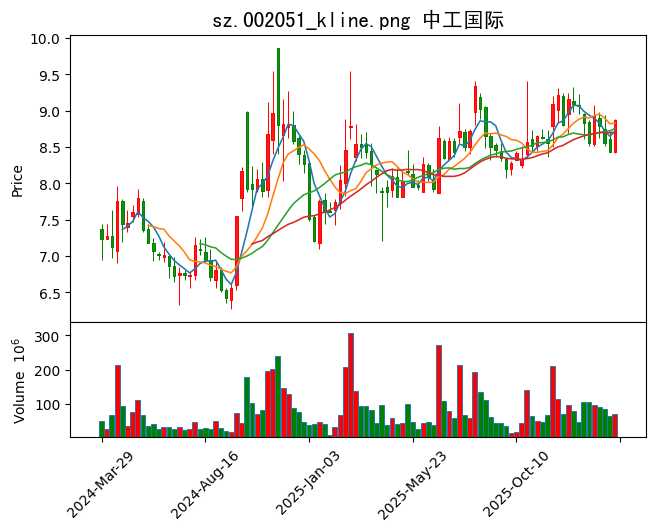

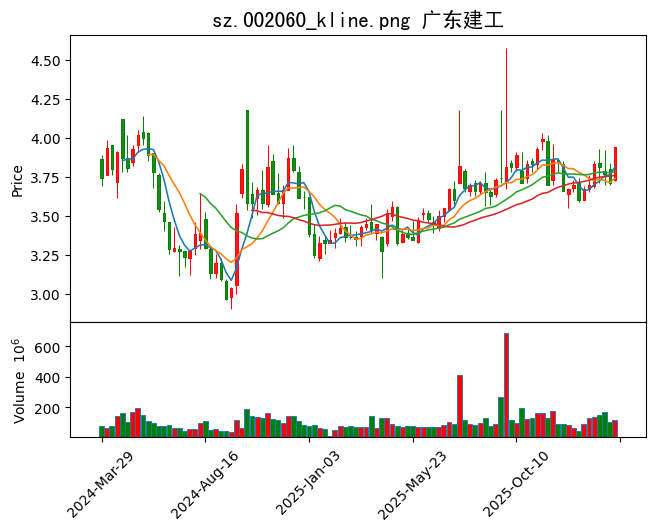

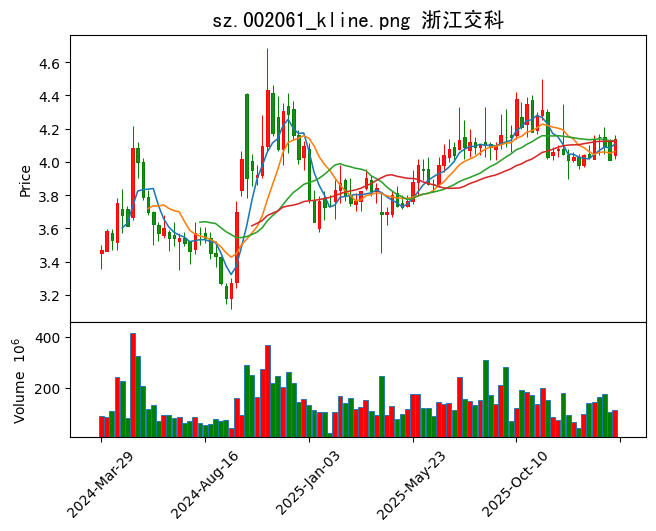

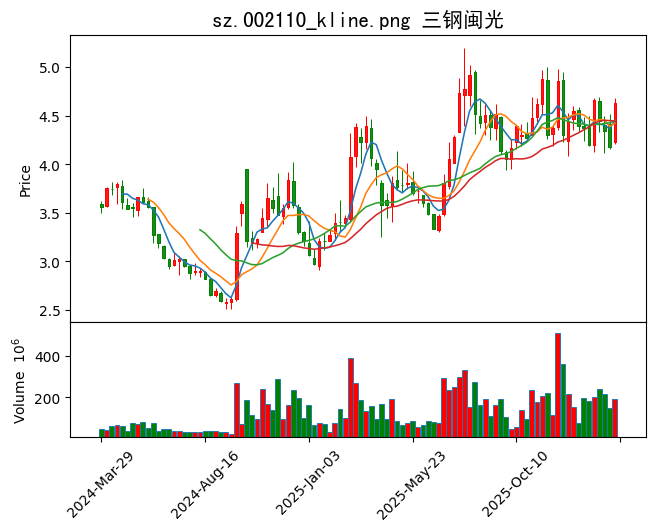

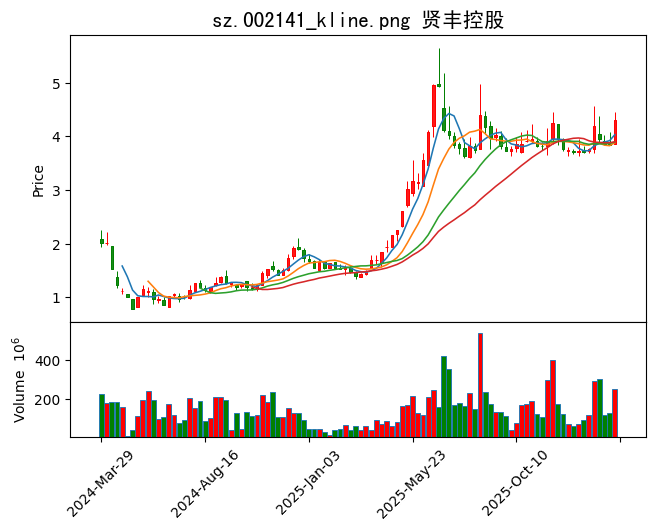

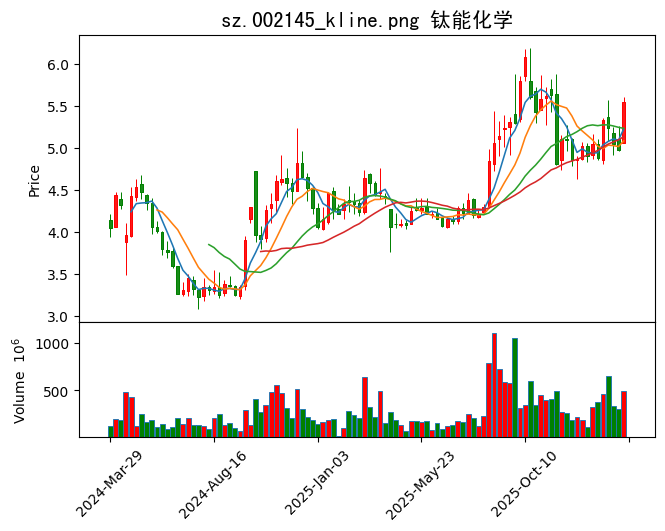

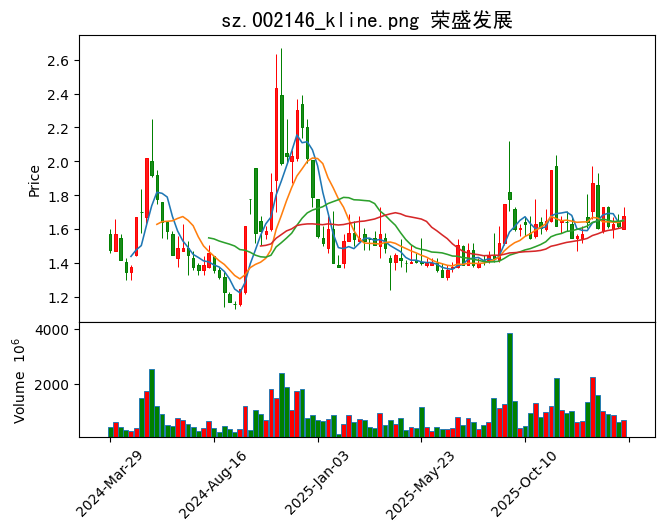

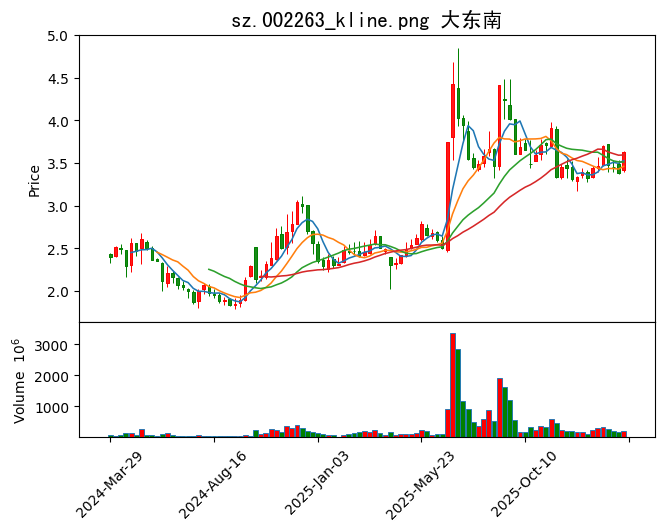

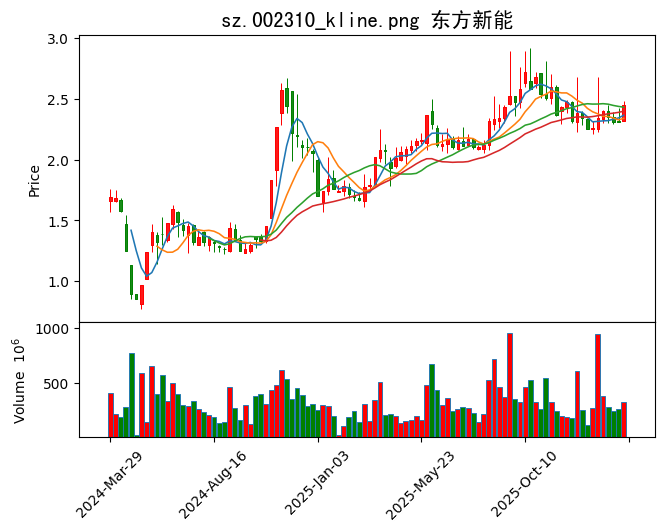

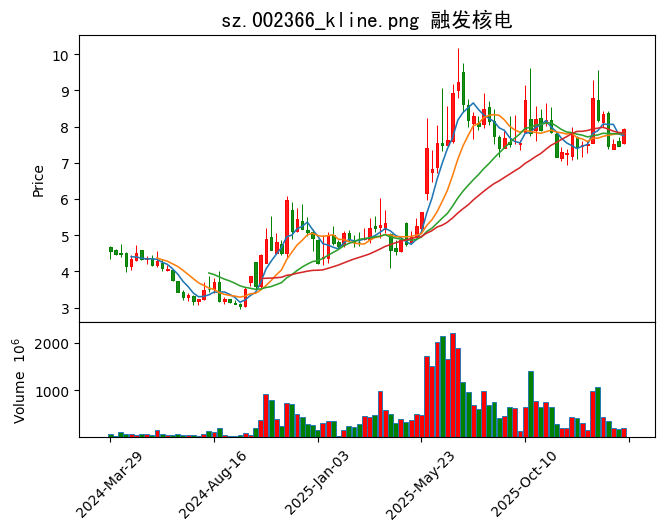

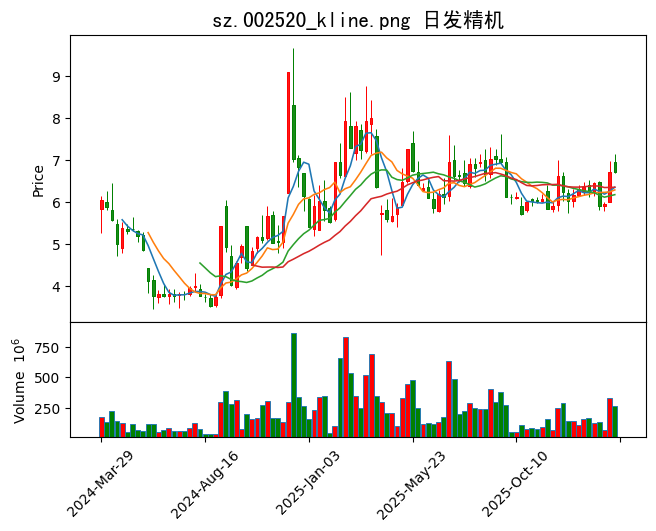

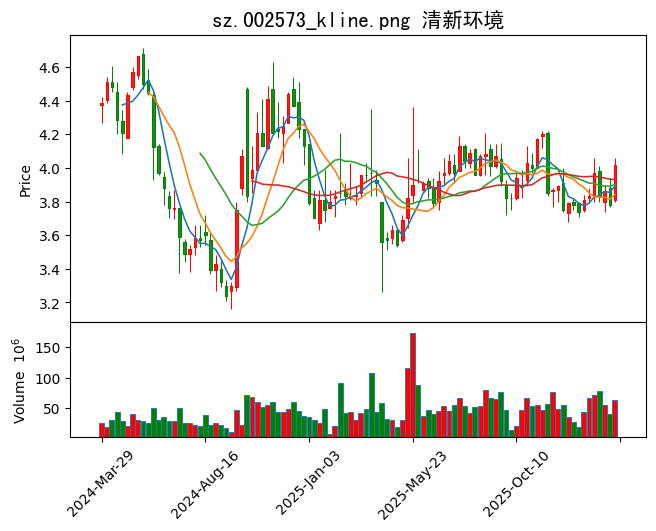

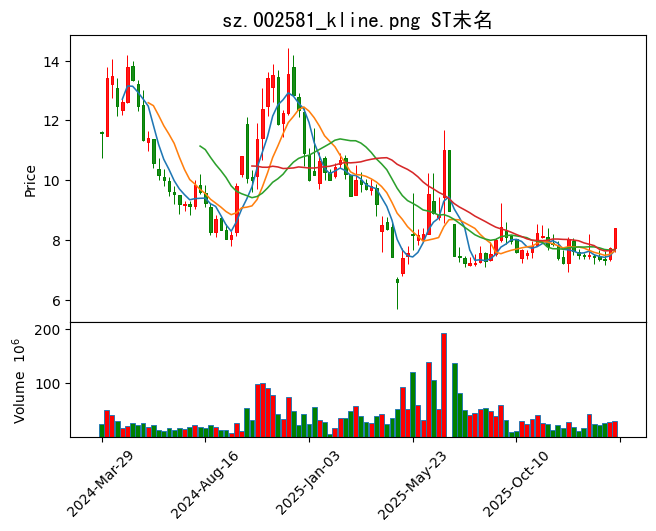

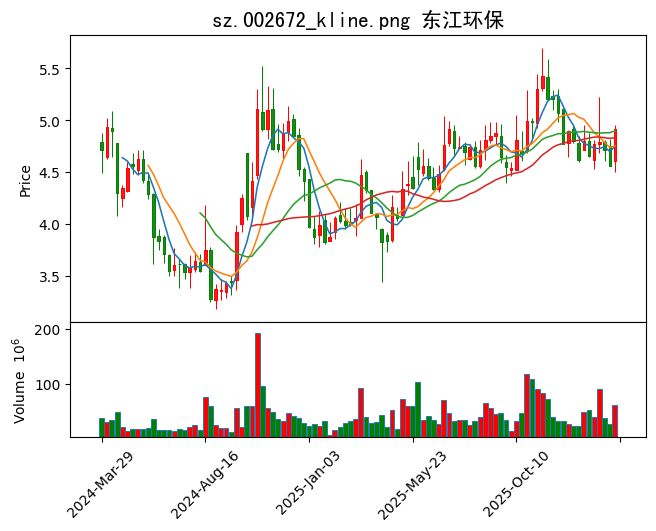

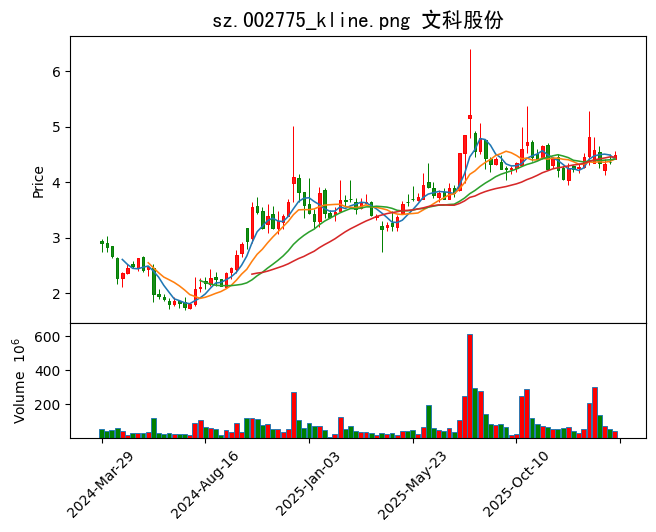

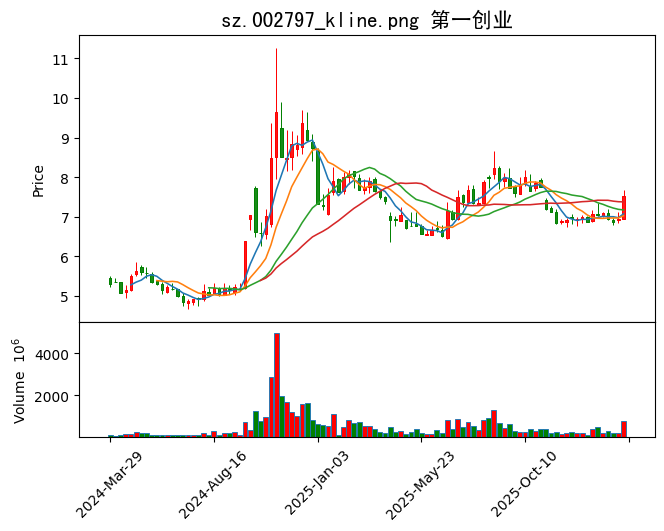

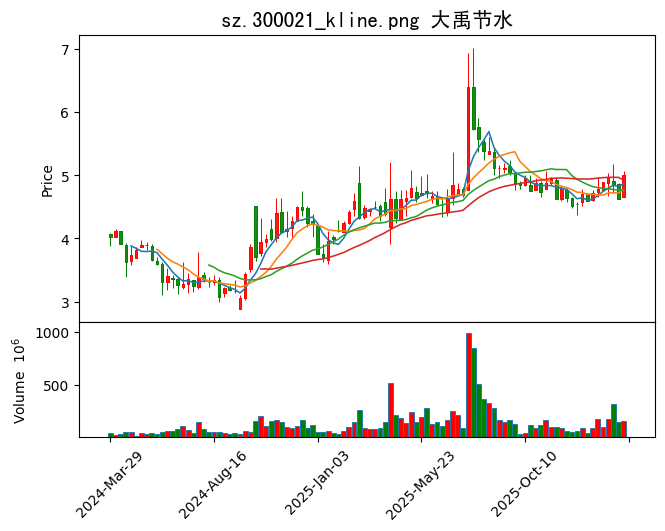

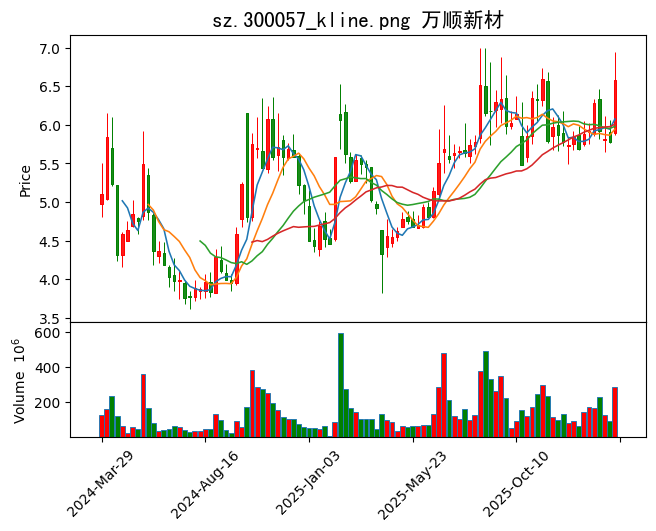

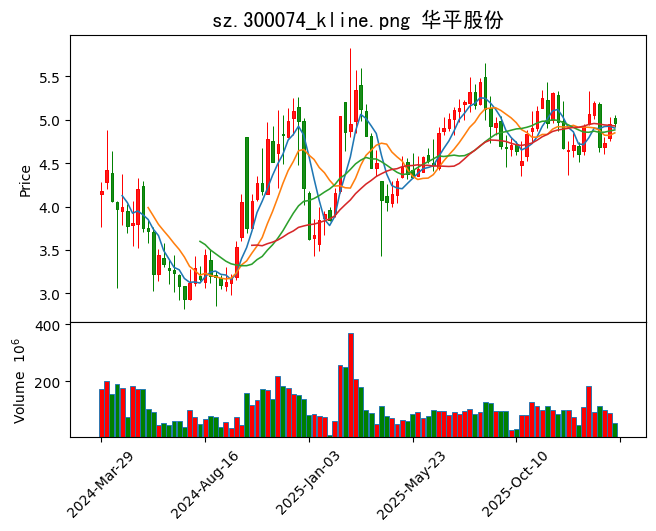

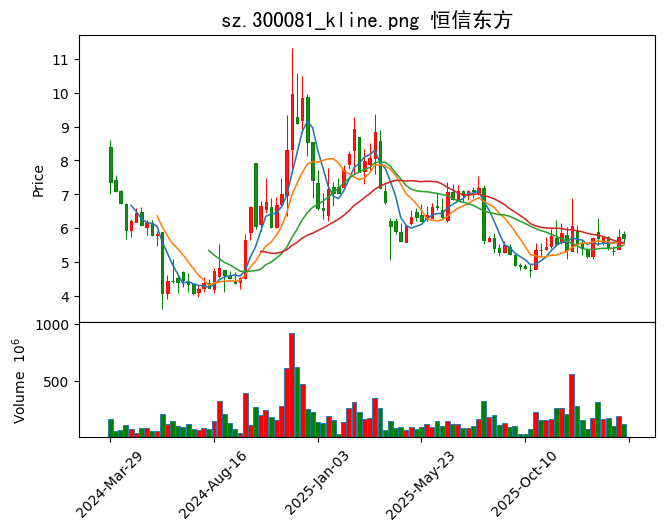

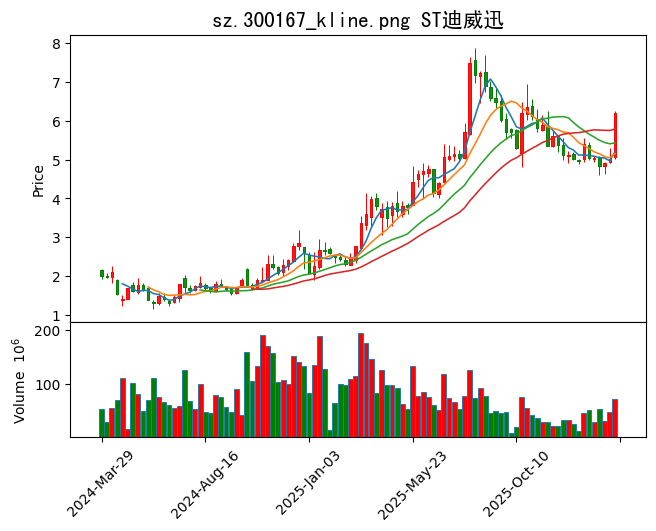

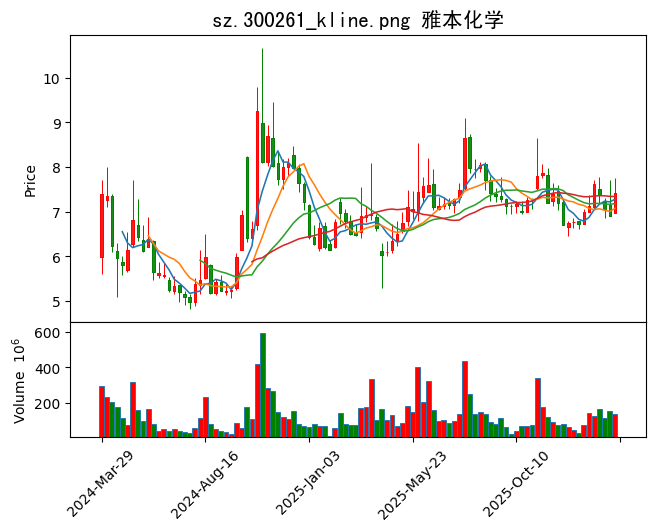

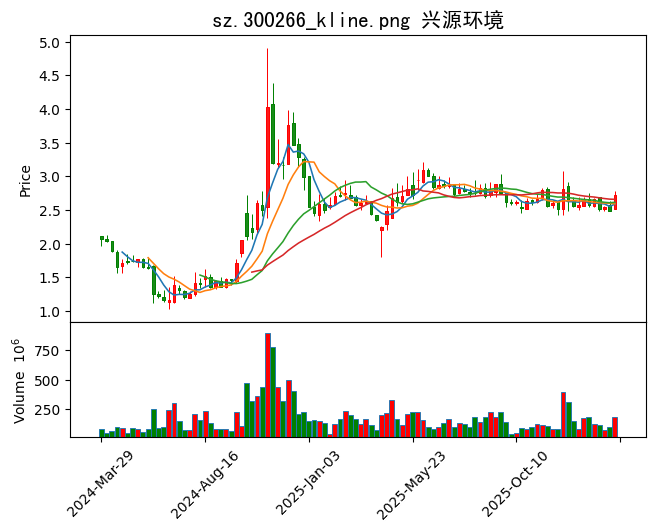

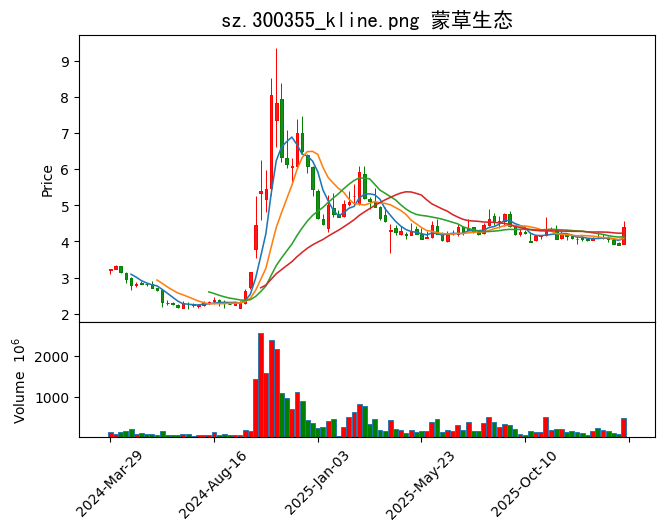

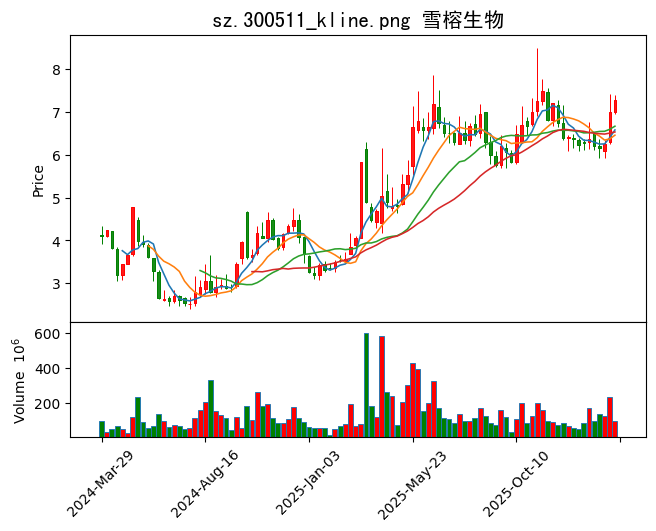

In [63]:
import mplfinance as mpf
def plot_kline(stock_code):
    os.makedirs("./k_plots", exist_ok=True)
    FILE_PATH = f'/mnt/d/forCoding_data/QuantFinance/plan_1-select_stock_by_week/originalData/{stock_code}.csv'
    OUTPUT_IMAGE = f'{stock_code}_kline.png'
    if not os.path.exists(FILE_PATH):
        print(f"错误: 找不到文件 {FILE_PATH}")
        return

    # print(f"正在读取文件: {FILE_PATH}")
    try:
        # 读取 CSV
        df = pd.read_csv(FILE_PATH)
        
        # 确保列名符合 mplfinance 的要求
        # mplfinance 需要索引为 DatetimeIndex，且列名为 Open, High, Low, Close, Volume
        
        # 转换日期列
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)
        
        # 重命名列以匹配 mplfinance (它不区分大小写，但最好规范一下)
        # 您的数据列名是: open, high, low, close, volume, amount, adjustflag, turn, pctChg
        # 只要包含 open, high, low, close, volume 即可
        
        # 截取最近的数据进行展示，以免数据量太大看不清 (例如最近 100 周)
        plot_df = df.tail(100)
        
        # print(f"正在绘制最近 {len(plot_df)} 周的 K 线图...")
        
        # 设置样式
        # type='candle': 蜡烛图
        # mav=(5, 10, 20): 移动平均线
        # volume=True: 显示成交量
        # style='charles': 常用样式 (红涨绿跌/绿涨红跌取决于样式，charles 是经典的红绿)
        mc = mpf.make_marketcolors(up='r', down='g', edge='i', wick='i', volume='in', inherit=True)
        s = mpf.make_mpf_style(marketcolors=mc)
    
        fig, axlist = mpf.plot(plot_df, 
                 type='candle', 
                 mav=(5, 10, 20, 30), 
                 volume=True, 
                 style=s,         
             returnfig=True  # <--- 必须显式添加这一行
                 # title=OUTPUT_IMAGE + " " + stock_name_map[stock_code],
                 # savefig=os.path.join("./k_plots", OUTPUT_IMAGE)
        )
        main_ax = axlist[0]
        main_ax.set_title(OUTPUT_IMAGE + " " + stock_name_map[stock_code], fontproperties=myfont, fontsize=15)
        fig.savefig(os.path.join("./k_plots", OUTPUT_IMAGE), bbox_inches='tight')
    except Exception as e:
        print(f"绘图失败: {e}")

for sc in tqdm.tqdm(selected_code):
    plot_kline(sc)